# OAI External Validation, Stratified by Coronal Deformity

Splits the OAI full-limb cohort into **varus / normal / valgus** and reports model performance
**within each stratum**, instead of one pooled number that hides where the model is strong and
where it is not.

Sibling notebooks: `hto_correction_angles_oai_external_validation.ipynb` (pooled HKA agreement)
and `hto_oai_split_by_deformity.ipynb` (writes the three subsets to disk). This one is
self-contained — it runs the model itself and does the stratified analysis in one pass.

---

### Design decisions worth knowing before you read any number

**1 · Strata are defined by OAI's clinical HKA, never by the prediction.**
A split on predicted HKA would fold the model's own errors into the group definitions and
flatter every per-stratum result. Ground-truth labelling keeps each stratum a fixed,
model-independent slice of the cohort.

| class  | rule (OAISYS convention: signed, 0 = neutral, negative = varus) |
|--------|------------------------------------------------------------------|
| varus  | `HKA < -NEUTRAL_BAND`                                              |
| normal | `|HKA| <= NEUTRAL_BAND`                                            |
| valgus | `HKA > +NEUTRAL_BAND`                                              |

`NEUTRAL_BAND = 3.0°` by default, matching the stratification already used in the pooled
notebook. Section 17 re-runs everything across bands 1–5° so the conclusions can be checked
against that choice.

**2 · One inference pass, strata applied afterwards.**
Three separate runs over three folders of copied DICOMs would give bit-identical predictions at
three times the cost and three times the disk. The model is run once over the whole cohort and
each knee carries its stratum label into the analysis. Section 18 can still materialise the
folders if another tool needs them.

**3 · Two of the three strata are outside the training domain.**
The model was trained on HTO candidates only, so it has seen varus legs and essentially
nothing else. `normal` and `valgus` are therefore not "harder subgroups" — they are
extrapolation, and the stratified result is a domain-shift measurement rather than a
subgroup analysis. `TRAIN_DOMAIN` in section 2 records this and the tables carry the label.

**4 · Knees are not independent.** Two knees share a radiograph, and one subject contributes
several visits. Every confidence interval here comes from a **cluster bootstrap resampling
subjects** (falling back to radiographs when `subj` is absent), not from the naive per-knee
formula, which would run roughly √2 too narrow.

**5 · Correlation statistics are range-restricted inside a stratum.**
The `normal` stratum spans 6° by construction, so ICC and Pearson *r* collapse there even when
accuracy is unchanged. Per stratum, read **MAE, bias and limits of agreement**; keep ICC for the
pooled cohort. The tables print both, with the restricted ones marked.

### What the notebook produces

- per-stratum agreement battery — MAE / RMSE / bias / 95 % LoA / ICC / *r*, each with a
  cluster-bootstrap 95 % CI, plus outlier-robust median and P95 error and the "within 1/2/3°" rates
- a between-stratum comparison: bootstrap ΔMAE contrasts, Kruskal–Wallis + Holm-adjusted pairwise
  tests, and a bias²/variance decomposition that says *why* a stratum is worse
- a proportional-bias fit and a calibration diagnostic separating shrinkage from localisation error
- a **triage** section: 3×3 confusion matrix, per-class sensitivity/specificity/PPV/NPV,
  Cohen's and linear-weighted κ, and ROC/AUC for detecting varus (the HTO-candidate screen)
- per-stratum inference-failure rates, a threshold sensitivity sweep, exported CSVs, and a
  verification cell that fails loudly if any of it is internally inconsistent

## 1 · Imports & Configuration

In [1]:
import os
import sys
import glob
import math
import json
import random
import shutil
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.optim as optim
from scipy.stats import pearsonr, spearmanr, kruskal, mannwhitneyu

for _ckd in ("CKD", "/tf/notebooks/CKD", os.path.join(os.getcwd(), "CKD")):
    if os.path.isdir(_ckd):
        sys.path.append(os.path.abspath(_ckd)); break
else:
    sys.path.append(os.path.abspath("CKD"))
from models import (
    Conformer_tiny_patch16_keypoint_half_heatmap,
    Conformer_small_patch16_keypoint_half_heatmap,
    Conformer_small_patch32_keypoint_half_heatmap,
    Conformer_base_patch16_keypoint_half_heatmap,
)
from utils import extract_coordinates

SEED          = 42
TARGET_SIZE   = 768
HEATMAP_SCALE = 0.5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware device registered: {device}")

GLOBAL_KEYPOINT_NAMES = [
    "femur_head_lh", "knee_inner_lh", "ost_point_lh",
    "knee_outer_lh", "ankle_inner_lh", "ankle_outer_lh",
    "femur_head_rh", "knee_inner_rh", "ost_point_rh",
    "knee_outer_rh", "ankle_inner_rh", "ankle_outer_rh",
]

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)

Hardware device registered: cuda


/usr/local/lib/python3.11/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/tf/notebooks/CKD/vision_transformer.py:370: UserWarning: Overwriting vit_small_patch16_224 in registry with vision_transformer.vit_small_patch16_224. This is because the name being registe

## 2 · OAI & Stratification Config — edit these

In [2]:
# ============================================================================
# Paths — same layout as hto_correction_angles_oai_external_validation.ipynb
# ============================================================================
OAI_IMAGE_DIR   = "/tf/data/hka/oai_dicoms"                          # extracted <barcode>.dcm
OAI_HKA_CSV     = "/tf/data/hka/oai_hka_groundtruth.csv"             # from prepare_oai_hka.py
CHECKPOINT_PATH = "/tf/notebooks/kfolds_models/best_model_global.pt"  # trained model
OUT_DIR         = "oai_deformity_stratified"                          # results land here

MODEL_VARIANT = "small_p16"

HKA_KEY_COL   = "barcode"        # == DICOM filename stem
HKA_SIDE1_COL = "hka_side1"
HKA_SIDE2_COL = "hka_side2"
SUBJ_COL      = "subj"           # clustering unit for the bootstrap; falls back to barcode

# ---- HKA convention -------------------------------------------------------
HKA_NEUTRAL_180    = False       # True only if HKA is stored as 180 = straight leg
IMAGE_LEFT_IS_SIDE = "1"         # image-hemisphere -> OAI side; section 9 confirms it
HKA_SIGN_FLIP      = False       # section 9 confirms this too

# ---- training domain: which strata the model has actually seen ------------
# The detector was trained only on HTO-candidate long-leg radiographs
# (Przystalski et al., Mendeley bpvj6xczm2) — a cohort that is varus by surgical
# indication. Stratum membership is therefore not merely a covariate: 'varus' is
# in-domain, 'normal' and 'valgus' are extrapolation. Set this to match your
# training cohort; it changes nothing computationally, it labels the reporting.
TRAIN_DOMAIN = {"varus": "in-domain", "normal": "OUT-of-domain", "valgus": "OUT-of-domain"}

# ---- stratification -------------------------------------------------------
NEUTRAL_BAND = 3.0               # deg; |HKA - neutral| <= band  =>  normal
CLASSES      = ("varus", "normal", "valgus")
BAND_SWEEP   = (1.0, 2.0, 3.0, 4.0, 5.0)     # section 16 sensitivity analysis

# ---- inference / QC -------------------------------------------------------
DICOM_INVERT    = False          # MONOCHROME1 handled automatically
EXCLUDE_ABS_DEV = 25.0           # |predicted HKA - neutral| beyond this => model failure
MAX_IMAGES      = None           # int to cap the run for a smoke test; None = whole cohort

# ---- inference ------------------------------------------------------------
N_BOOT     = 2000                # cluster-bootstrap replicates
BOOT_SEED  = 20260823
CI_ALPHA   = 0.05

# ---- optional: also write varus/normal/valgus folders of image copies -----
MATERIALISE_SUBSETS = False      # section 17; the analysis never needs it
SUBSET_ROOT         = "/tf/data/hka/oai_by_deformity"
COPY_MODE           = "copy"     # "copy" | "hardlink" | "symlink"

IMG_EXTS = (".dcm", ".dicom", ".png", ".jpg", ".jpeg", ".tif", ".tiff")
NEUTRAL  = 180.0 if HKA_NEUTRAL_180 else 0.0
PALETTE  = {"varus": "#B3572B", "normal": "#4C6EB1", "valgus": "#2E7D32", "POOLED": "#444444"}

os.makedirs(OUT_DIR, exist_ok=True)
print(f"Strata (deg, neutral = {NEUTRAL:.0f}):  "
      f"varus < {NEUTRAL - NEUTRAL_BAND:+.1f} | "
      f"normal {NEUTRAL - NEUTRAL_BAND:+.1f}..{NEUTRAL + NEUTRAL_BAND:+.1f} | "
      f"valgus > {NEUTRAL + NEUTRAL_BAND:+.1f}")
print(f"Results -> {os.path.abspath(OUT_DIR)}")

Strata (deg, neutral = 0):  varus < -3.0 | normal -3.0..+3.0 | valgus > +3.0
Results -> /tf/notebooks/oai_deformity_stratified


## 3 · Image Loading & Preprocessing

Identical to the pooled validation notebook, so predictions are comparable cell-for-cell.

In [3]:
def preprocess_global_image(img, target_size=512):
    """Letterbox-resize *img* to a square canvas of *target_size* pixels."""
    orig_w, orig_h = img.size
    scale   = min(target_size / orig_w, target_size / orig_h)
    new_w   = int(orig_w * scale)
    new_h   = int(orig_h * scale)
    resized = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    pad_left = (target_size - new_w) // 2
    pad_top  = (target_size - new_h) // 2
    final_img = Image.new("RGB", (target_size, target_size), (0, 0, 0))
    final_img.paste(resized, (pad_left, pad_top))
    return final_img, scale, (pad_left, pad_top)


def load_oai_image(path):
    """Load an OAI radiograph as an RGB PIL image (handles DICOM windowing / inversion)."""
    ext = os.path.splitext(path)[1].lower()
    if ext in (".dcm", ".dicom", ""):
        import pydicom
        ds  = pydicom.dcmread(path)
        arr = ds.pixel_array.astype(np.float32)
        slope = ds.get("RescaleSlope", 1.0);     slope = 1.0 if slope in (None, "") else float(slope)
        inter = ds.get("RescaleIntercept", 0.0); inter = 0.0 if inter in (None, "") else float(inter)
        arr = arr * slope + inter
        lo, hi = np.percentile(arr, (1, 99))                       # robust window
        arr = np.clip((arr - lo) / max(hi - lo, 1e-6), 0.0, 1.0)
        if ds.get("PhotometricInterpretation", "") == "MONOCHROME1" or DICOM_INVERT:
            arr = 1.0 - arr
        return Image.fromarray((arr * 255).astype(np.uint8)).convert("RGB")
    return Image.open(path).convert("RGB")


_IMNET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_IMNET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def to_model_tensor(pil):
    t = torch.from_numpy(np.array(pil)).permute(2, 0, 1).float() / 255.0
    return (t - _IMNET_MEAN) / _IMNET_STD

## 4 · HKA from Predicted Landmarks

In [4]:
# Slots within each hemisphere: 0 femur_head | 1 knee_inner | 2 ost_point | 3 knee_outer
#                               4 ankle_inner | 5 ankle_outer   (ost_point unused for HKA)
def hka_from_side(pts6, neutral180=None, sign_flip=None):
    if neutral180 is None: neutral180 = HKA_NEUTRAL_180
    if sign_flip is None:  sign_flip  = HKA_SIGN_FLIP
    fh = pts6[0]; ki = pts6[1]; ko = pts6[3]
    kc = 0.5 * (ki + ko); ac = 0.5 * (pts6[4] + pts6[5])
    vf = fh - kc; vt = ac - kc                                  # knee->hip, knee->ankle
    cross = vf[0]*vt[1] - vf[1]*vt[0]; dot = vf[0]*vt[0] + vf[1]*vt[1]
    ang = abs(math.degrees(math.atan2(cross, dot)))             # ~180 for a straight leg
    dev = 180.0 - ang
    # laterality-consistent sign: knee_outer(lateral) - knee_inner(medial) is THIS leg's
    # medial->lateral direction, so the same clinical deformity gets the same sign on the
    # left and right legs (their raw cross-product signs are mirror-opposite otherwise).
    lat  = 1.0 if (ko[0] - ki[0]) >= 0 else -1.0
    sign = (-1.0 if cross < 0 else 1.0) * lat * (-1.0 if sign_flip else 1.0)
    return (180.0 - sign*dev) if neutral180 else (sign*dev)


def predict_landmarks(pil):
    """OAI image -> [12,2] landmark coords in 768 letterbox space (angle-preserving)."""
    canon, _, _ = preprocess_global_image(pil, TARGET_SIZE)
    with torch.no_grad():
        hms = torch.sigmoid(model_global(to_model_tensor(canon).unsqueeze(0).to(device)))
    return extract_coordinates(hms.cpu(), scale_factor=1.0 / HEATMAP_SCALE)[0].numpy()


# self-tests: a straight synthetic leg must give HKA = 180, and mirrored legs must agree
_straight = np.array([[100,0],[90,500],[0,0],[110,500],[90,1000],[110,1000]], float)
assert abs(hka_from_side(_straight, neutral180=True, sign_flip=False) - 180.0) < 0.1, "HKA self-test failed"
_vL = np.array([[400,100],[415,500],[0,0],[385,500],[450,900],[430,900]], float)  # image-left,  varus
_vR = np.array([[400,100],[385,500],[0,0],[415,500],[350,900],[370,900]], float)  # image-right, mirror
assert abs(hka_from_side(_vL) - hka_from_side(_vR)) < 1e-6, "left/right sign inconsistent"
print("HKA self-tests passed (straight -> 180; mirrored legs share sign).")

HKA self-tests passed (straight -> 180; mirrored legs share sign).


## 5 · Model & Checkpoint

In [5]:
_model_map = {
    "tiny":      Conformer_tiny_patch16_keypoint_half_heatmap,
    "small_p16": Conformer_small_patch16_keypoint_half_heatmap,
    "small_p32": Conformer_small_patch32_keypoint_half_heatmap,
    "base":      Conformer_base_patch16_keypoint_half_heatmap,
}

model_global = _model_map[MODEL_VARIANT](num_keypoints=12).to(device)

if os.path.exists(CHECKPOINT_PATH):
    model_global.load_state_dict(torch.load(CHECKPOINT_PATH, weights_only=True, map_location=device))
    model_global.eval()
    print(f"Model '{MODEL_VARIANT}' loaded from '{CHECKPOINT_PATH}' on {device}.")
else:
    raise FileNotFoundError(
        f"Checkpoint '{CHECKPOINT_PATH}' not found — set CHECKPOINT_PATH in section 2."
    )

Model 'small_p16' loaded from '/tf/notebooks/kfolds_models/best_model_global.pt' on cuda.


## 6 · Ground Truth & Deformity Strata

One row per knee, labelled from OAI's clinical HKA. `side` follows the OAI column it came from
(`hka_side1` -> `"1"`), the same key the inference loop matches on via `IMAGE_LEFT_IS_SIDE`.

In [6]:
hka_df = pd.read_csv(OAI_HKA_CSV, dtype={HKA_KEY_COL: str})
hka_df[HKA_KEY_COL] = hka_df[HKA_KEY_COL].astype(str).str.strip()
if hka_df[HKA_KEY_COL].duplicated().any():
    n_dup = int(hka_df[HKA_KEY_COL].duplicated().sum())
    hka_df = hka_df.drop_duplicates(HKA_KEY_COL, keep="first").reset_index(drop=True)
    print(f"WARNING: dropped {n_dup} duplicate barcode row(s), kept first.")
for col in (HKA_SIDE1_COL, HKA_SIDE2_COL):
    hka_df[col] = pd.to_numeric(hka_df[col], errors="coerce")
hka_lookup = hka_df.set_index(HKA_KEY_COL)

# OAI's own inter-reader SD — the benchmark the model is trying to approach
oai_reader_sd = np.nan
if {"readsd_side1", "readsd_side2"}.issubset(hka_df.columns):
    oai_reader_sd = float(pd.concat([hka_df["readsd_side1"],
                                     hka_df["readsd_side2"]]).dropna().mean())

# ---- source images, indexed by filename stem (== barcode) ----
src_paths = sorted(p for p in glob.glob(os.path.join(OAI_IMAGE_DIR, "*"))
                   if os.path.splitext(p)[1].lower() in IMG_EXTS)
src_index = {}
for p in src_paths:
    src_index.setdefault(os.path.splitext(os.path.basename(p))[0], p)


def classify(hka, neutral=None, band=None):
    """Signed HKA -> 'varus' | 'normal' | 'valgus'   (None when missing)."""
    neutral = NEUTRAL if neutral is None else neutral
    band    = NEUTRAL_BAND if band is None else band
    if hka is None or pd.isna(hka):
        return None
    dev = float(hka) - neutral
    if dev < -band: return "varus"
    if dev >  band: return "valgus"
    return "normal"


# boundary self-test: the neutral band is inclusive on both edges
assert [classify(v) for v in (NEUTRAL - NEUTRAL_BAND, NEUTRAL, NEUTRAL + NEUTRAL_BAND)] == ["normal"] * 3
assert classify(NEUTRAL - NEUTRAL_BAND - 0.01) == "varus"
assert classify(NEUTRAL + NEUTRAL_BAND + 0.01) == "valgus"
assert classify(np.nan) is None
print("classify() self-test passed.")

# ---- per-knee manifest: the stratum definition, fixed before any inference ----
knee_rows = []
for _, r in hka_df.iterrows():
    bc = r[HKA_KEY_COL]
    for side, col in (("1", HKA_SIDE1_COL), ("2", HKA_SIDE2_COL)):
        cls = classify(r[col])
        if cls is None:
            continue
        knee_rows.append(dict(
            barcode=bc, side=side, oai_hka=float(r[col]), deformity=cls,
            has_image=bc in src_index,
            subj=str(r[SUBJ_COL]) if SUBJ_COL in hka_df.columns and pd.notna(r.get(SUBJ_COL)) else bc,
            visit=r.get("visit"), sex=r.get("sex"), ageyears=r.get("ageyears"),
            readsd=r.get(f"readsd_side{side}"),
        ))
knee_manifest = pd.DataFrame(knee_rows)
n_knees = int(hka_df[[HKA_SIDE1_COL, HKA_SIDE2_COL]].notna().sum().sum())
assert len(knee_manifest) == n_knees, "knee count drifted from the ground-truth table"

CLUSTER_COL = "subj" if (SUBJ_COL in hka_df.columns and knee_manifest["subj"].nunique() > 1
                         and knee_manifest["subj"].nunique() < len(knee_manifest)) else "barcode"

print(f"Ground truth : {len(hka_df)} full-limb images / {n_knees} knees with HKA")
print(f"Source images: {len(src_paths)} files in {OAI_IMAGE_DIR}  "
      f"({int(knee_manifest['has_image'].sum())} knees have an image on disk)")
print(f"Bootstrap clustering unit: {CLUSTER_COL} "
      f"({knee_manifest[CLUSTER_COL].nunique()} clusters for {len(knee_manifest)} knees)")
if np.isfinite(oai_reader_sd):
    print(f"OAI within-knee inter-reader SD: {oai_reader_sd:.3f} deg  <- benchmark to approach")
knee_manifest.head()

classify() self-test passed.
Ground truth : 3831 full-limb images / 7647 knees with HKA
Source images: 3831 files in /tf/data/hka/oai_dicoms  (7647 knees have an image on disk)
Bootstrap clustering unit: subj (3740 clusters for 7647 knees)
OAI within-knee inter-reader SD: 0.298 deg  <- benchmark to approach


,barcode,side,oai_hka,deformity,has_image,subj,visit,sex,ageyears,readsd
0,16600375104,1,0.150000,normal,True,9454100,V01,F,59,0.086603
1,16600375104,2,2.436667,normal,True,9454100,V01,F,59,0.629312
2,16600376806,1,-5.865000,varus,True,9774237,V03,F,72,0.615183
3,16600376806,2,-1.780000,normal,True,9774237,V03,F,72,0.311127
4,16600756404,1,3.553333,valgus,True,9566704,V01,F,60,0.254034


## 7 · Cohort Composition

OAI COHORT BY CORONAL DEFORMITY   (neutral band +/-3.0 deg)
  varus   knees= 2155 ( 28.2%)  HKA  -5.26 +/- 2.01 deg  [ -16.6,   -3.0]  span= 13.6
  normal  knees= 4822 ( 63.1%)  HKA  -0.31 +/- 1.62 deg  [  -3.0,   +3.0]  span=  6.0
  valgus  knees=  670 (  8.8%)  HKA  +5.00 +/- 2.05 deg  [  +3.0,  +18.9]  span= 15.8
  TOTAL   knees= 7647          HKA  -1.24 +/- 3.42 deg

Note the span column: it is the reason ICC and r are not comparable across strata.


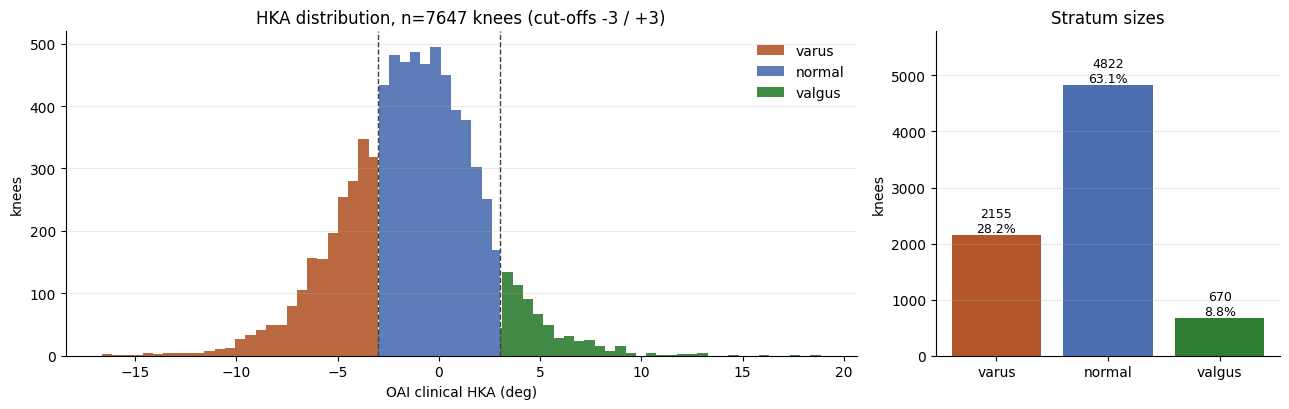

,deformity,knees,knees_with_image,subjects,hka_mean,hka_sd,hka_min,hka_max,pct
0,varus,2155,2155,1483,-5.263243,2.008750,-16.65,-3.005,28.180986
1,normal,4822,4822,2967,-0.307574,1.618373,-3.00,3.000,63.057408
2,valgus,670,670,532,4.996095,2.053005,3.01,18.860,8.761606


In [7]:
avail = knee_manifest[knee_manifest["has_image"]]
cohort = pd.DataFrame([
    dict(deformity=c,
         knees=int((knee_manifest["deformity"] == c).sum()),
         knees_with_image=int((avail["deformity"] == c).sum()),
         subjects=int(knee_manifest.loc[knee_manifest["deformity"] == c, CLUSTER_COL].nunique()),
         hka_mean=knee_manifest.loc[knee_manifest["deformity"] == c, "oai_hka"].mean(),
         hka_sd=knee_manifest.loc[knee_manifest["deformity"] == c, "oai_hka"].std(ddof=1),
         hka_min=knee_manifest.loc[knee_manifest["deformity"] == c, "oai_hka"].min(),
         hka_max=knee_manifest.loc[knee_manifest["deformity"] == c, "oai_hka"].max())
    for c in CLASSES
])
cohort["pct"] = 100 * cohort["knees"] / max(len(knee_manifest), 1)

print("=" * 78)
print(f"OAI COHORT BY CORONAL DEFORMITY   (neutral band +/-{NEUTRAL_BAND:.1f} deg)")
print("=" * 78)
for _, s in cohort.iterrows():
    print(f"  {s['deformity']:7s} knees={s['knees']:5d} ({s['pct']:5.1f}%)  "
          f"HKA {s['hka_mean']:+6.2f} +/- {s['hka_sd']:4.2f} deg  "
          f"[{s['hka_min']:+6.1f}, {s['hka_max']:+6.1f}]  span={s['hka_max']-s['hka_min']:5.1f}")
print(f"  {'TOTAL':7s} knees={len(knee_manifest):5d}          "
      f"HKA {knee_manifest['oai_hka'].mean():+6.2f} +/- {knee_manifest['oai_hka'].std(ddof=1):4.2f} deg")
print("\nNote the span column: it is the reason ICC and r are not comparable across strata.")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [2.3, 1]})
bins = np.union1d(np.histogram_bin_edges(knee_manifest["oai_hka"].values, bins=70),
                  [NEUTRAL - NEUTRAL_BAND, NEUTRAL + NEUTRAL_BAND])   # cut-offs as exact edges
for c in CLASSES:
    ax1.hist(knee_manifest.loc[knee_manifest["deformity"] == c, "oai_hka"].values,
             bins=bins, color=PALETTE[c], alpha=0.9, label=c)
for cut in (NEUTRAL - NEUTRAL_BAND, NEUTRAL + NEUTRAL_BAND):
    ax1.axvline(cut, color="0.25", ls="--", lw=1)
ax1.set_xlabel("OAI clinical HKA (deg)"); ax1.set_ylabel("knees")
ax1.set_title(f"HKA distribution, n={len(knee_manifest)} knees "
              f"(cut-offs {NEUTRAL-NEUTRAL_BAND:+.0f} / {NEUTRAL+NEUTRAL_BAND:+.0f})")
ax1.legend(frameon=False); ax1.spines[["top", "right"]].set_visible(False); ax1.grid(axis="y", alpha=0.25)

ax2.bar(cohort["deformity"], cohort["knees"], color=[PALETTE[c] for c in cohort["deformity"]])
for i, (v, p) in enumerate(zip(cohort["knees"], cohort["pct"])):
    ax2.text(i, v, f"{int(v)}\n{p:.1f}%", ha="center", va="bottom", fontsize=9)
ax2.set_ylabel("knees"); ax2.set_title("Stratum sizes")
ax2.set_ylim(0, cohort["knees"].max() * 1.20)
ax2.spines[["top", "right"]].set_visible(False); ax2.grid(axis="y", alpha=0.25)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "cohort_composition.png"), dpi=150, bbox_inches="tight")
plt.show()
cohort

## 8 · Inference — one pass over the whole cohort

Every matched image is run once; each knee then carries the stratum label fixed in section 6.
Running the three strata as separate passes would produce bit-identical predictions at three
times the cost.

In [8]:
model_global.eval()
paths = [p for p in src_paths
         if os.path.splitext(os.path.basename(p))[0] in set(hka_df[HKA_KEY_COL])]
if MAX_IMAGES:
    paths = paths[:int(MAX_IMAGES)]
print(f"{len(paths)} images matched to ground truth; running inference...")

knee_key = {(r.barcode, r.side): r for r in knee_manifest.itertuples()}
oai_results, diag_records = [], []
n_images = n_failed = 0

try:
    from tqdm.auto import tqdm
    pbar = tqdm(paths, desc="OAI inference", unit="img"); use_tqdm = True
except Exception:
    pbar = paths; use_tqdm = False

for i, path in enumerate(pbar):
    stem = os.path.splitext(os.path.basename(path))[0]
    n_images += 1
    try:
        coords = predict_landmarks(load_oai_image(path))              # [12,2] in 768 space
    except Exception:
        n_failed += 1
        continue

    p_left  = hka_from_side(coords[0:6])                              # image-left leg  (slots 0-5)
    p_right = hka_from_side(coords[6:12])                             # image-right leg (slots 6-11)
    pred_side = ({"1": p_left, "2": p_right} if IMAGE_LEFT_IS_SIDE == "1"
                 else {"1": p_right, "2": p_left})

    row = hka_lookup.loc[stem]
    if isinstance(row, pd.DataFrame):
        row = row.iloc[0]
    diag_records.append(dict(barcode=stem, img_left=p_left, img_right=p_right,
                             oai_side1=pd.to_numeric(row.get(HKA_SIDE1_COL), errors="coerce"),
                             oai_side2=pd.to_numeric(row.get(HKA_SIDE2_COL), errors="coerce")))

    for side in ("1", "2"):
        k = knee_key.get((stem, side))
        if k is None:                                                 # no HKA for this knee
            continue
        pred = float(pred_side[side])
        oai_results.append(dict(
            barcode=stem, side=side, subj=k.subj, visit=k.visit,
            pred_hka=pred, oai_hka=float(k.oai_hka), deformity=k.deformity,
            signed_err=pred - float(k.oai_hka), abs_err=abs(pred - float(k.oai_hka)),
            readsd=k.readsd,
            flagged=bool(abs(pred - NEUTRAL) > EXCLUDE_ABS_DEV),
        ))
    if use_tqdm:
        pbar.set_postfix(knees=len(oai_results), failed=n_failed)
    elif i % 200 == 0:
        print(f"  {i}/{len(paths)} images | knees {len(oai_results)}, failed {n_failed}", flush=True)

R = pd.DataFrame(oai_results)
R["deformity"] = pd.Categorical(R["deformity"], categories=list(CLASSES), ordered=True)
assert len(R) > 0, "no knees produced — check OAI_IMAGE_DIR / OAI_HKA_CSV / barcode matching"
assert not R.duplicated(["barcode", "side"]).any(), "a knee was scored twice"

print(f"\n{len(R)} knees from {n_images} images ({n_failed} inference failures, "
      f"{int(R['flagged'].sum())} flagged |HKA-neutral| > {EXCLUDE_ABS_DEV:.0f} deg).")
print(R.groupby("deformity", observed=False).size().to_string())

3831 images matched to ground truth; running inference...


OAI inference:   0%|          | 0/3831 [00:00<?, ?img/s]


7647 knees from 3831 images (0 inference failures, 475 flagged |HKA-neutral| > 25 deg).
deformity
varus     2155
normal    4822
valgus     670


## 9 · Laterality / Sign Check

**Read this before any stratum table.** If `IMAGE_LEFT_IS_SIDE` or `HKA_SIGN_FLIP` is wrong, the
predictions are mirrored against ground truth and every per-stratum number below is meaningless —
varus knees get scored against valgus predictions. The cell picks the configuration with the
highest correlation and warns if it is not the one currently set.

In [9]:
D = pd.DataFrame(diag_records)

def _corr_under(left_is_side1, flip):
    rows = []
    for d in D.itertuples():
        pl, pr = d.img_left, d.img_right
        if flip:
            pl = (360.0 - pl) if HKA_NEUTRAL_180 else -pl
            pr = (360.0 - pr) if HKA_NEUTRAL_180 else -pr
        ps = ({"1": pl, "2": pr} if left_is_side1 else {"1": pr, "2": pl})
        for s, g in (("1", d.oai_side1), ("2", d.oai_side2)):
            if pd.notna(g):
                rows.append((ps[s], g))
    if len(rows) < 3:
        return float("nan")
    a = np.asarray(rows, float)
    keep = np.abs(a[:, 0] - NEUTRAL) <= EXCLUDE_ABS_DEV          # ignore model failures here
    a = a[keep] if keep.sum() > 10 else a
    return pearsonr(a[:, 0], a[:, 1])[0]

opts = {(True, False): 'IMAGE_LEFT_IS_SIDE="1", HKA_SIGN_FLIP=False',
        (False, False): 'IMAGE_LEFT_IS_SIDE="2", HKA_SIGN_FLIP=False',
        (True, True): 'IMAGE_LEFT_IS_SIDE="1", HKA_SIGN_FLIP=True',
        (False, True): 'IMAGE_LEFT_IS_SIDE="2", HKA_SIGN_FLIP=True'}
scores = {k: _corr_under(*k) for k in opts}
best = max(scores, key=lambda k: (scores[k] if np.isfinite(scores[k]) else -np.inf))
current = (IMAGE_LEFT_IS_SIDE == "1", HKA_SIGN_FLIP)

print("Pearson r under each laterality/sign configuration:")
for k, lbl in opts.items():
    mark = "  <- current" if k == current else ""
    star = " *best*" if k == best else ""
    print(f"  r={scores[k]:+.3f}   {lbl}{star}{mark}")

if best != current:
    print("\n" + "!" * 78)
    print("STOP: the best configuration is not the one set in section 2.")
    print(f"      set {opts[best]} and re-run from section 8.")
    print("!" * 78)
elif not np.isfinite(scores[best]) or scores[best] < 0.3:
    print("\nWARNING: even the best configuration correlates weakly. Predictions are probably "
          "not localising — check the overlay diagnostic in the pooled notebook before reading on.")
else:
    print(f"\nConfiguration confirmed (r={scores[best]:+.3f}). Stratum results below are trustworthy.")

Pearson r under each laterality/sign configuration:
  r=+0.758   IMAGE_LEFT_IS_SIDE="1", HKA_SIGN_FLIP=False *best*  <- current
  r=+0.459   IMAGE_LEFT_IS_SIDE="2", HKA_SIGN_FLIP=False
  r=-0.758   IMAGE_LEFT_IS_SIDE="1", HKA_SIGN_FLIP=True
  r=-0.459   IMAGE_LEFT_IS_SIDE="2", HKA_SIGN_FLIP=True

Configuration confirmed (r=+0.758). Stratum results below are trustworthy.


## 10 · Statistical Toolkit

Two knees share a radiograph and one subject contributes several visits, so the effective sample
size is well below the knee count. Every interval below therefore comes from a **cluster
bootstrap over `CLUSTER_COL`** — whole subjects are resampled with replacement — rather than the
naive per-knee formula.

In [10]:
def icc21(M):
    """ICC(2,1), two-way random effects, absolute agreement, single measurement."""
    X = np.asarray(M, float); n, k = X.shape; g = X.mean()
    if n < 3:
        return np.nan
    SSR = k * ((X.mean(1) - g) ** 2).sum(); SSC = n * ((X.mean(0) - g) ** 2).sum()
    SSE = ((X - g) ** 2).sum() - SSR - SSC
    MSR = SSR / (n - 1); MSC = SSC / (k - 1); MSE = SSE / ((n - 1) * (k - 1))
    denom = MSR + (k - 1) * MSE + (k / n) * (MSC - MSE)
    return (MSR - MSE) / denom if denom != 0 else np.nan


def _cluster_index(clusters):
    """Rows grouped contiguously by cluster -> (order, starts, lens) for fast resampling."""
    c = pd.factorize(np.asarray(clusters))[0]
    order  = np.argsort(c, kind="stable"); sc = c[order]
    starts = np.flatnonzero(np.r_[True, sc[1:] != sc[:-1]])
    lens   = np.diff(np.r_[starts, len(sc)])
    return order, starts, lens


def cluster_bootstrap(stat_fn, clusters, n_boot=None, seed=None):
    """Resample whole clusters with replacement; stat_fn(row_indices) -> scalar or 1-D array."""
    n_boot = N_BOOT if n_boot is None else n_boot
    seed   = BOOT_SEED if seed is None else seed
    order, starts, lens = _cluster_index(clusters)
    k = len(starts); rng = np.random.default_rng(seed); out = []
    for _ in range(n_boot):
        c   = rng.integers(0, k, k)
        L   = lens[c]; tot = int(L.sum())
        off = np.arange(tot) - np.repeat(np.cumsum(L) - L, L)     # position inside each cluster
        out.append(stat_fn(order[np.repeat(starts[c], L) + off]))
    return np.asarray(out, float)


def boot_ci(v, alpha=None):
    alpha = CI_ALPHA if alpha is None else alpha
    v = np.asarray(v, float); v = v[np.isfinite(v)]
    if v.size < 10:
        return (np.nan, np.nan)
    return tuple(np.percentile(v, [100 * alpha / 2, 100 * (1 - alpha / 2)]))


_AGREE_KEYS = ("mae", "bias", "sd", "rmse", "icc", "pearson_r")

def _agree_vec(pred, oai):
    d = pred - oai; n = len(d)
    if n < 3:
        return np.full(len(_AGREE_KEYS), np.nan)
    sd = d.std(ddof=1)
    r  = pearsonr(pred, oai)[0] if pred.std() > 0 and oai.std() > 0 else np.nan
    return np.array([np.abs(d).mean(), d.mean(), sd,
                     float(np.sqrt((d ** 2).mean())), icc21(np.c_[pred, oai]), r])


def agreement(df, name, clusters=None, n_boot=None):
    """Full agreement battery for one subset, with cluster-bootstrap CIs."""
    pred = df["pred_hka"].to_numpy(float); oai = df["oai_hka"].to_numpy(float)
    d = pred - oai; n = len(d)
    mae, bias, sd, rmse, icc, r = _agree_vec(pred, oai)
    res = dict(subset=name, n=n,
               n_clusters=int(pd.Series(clusters).nunique()) if clusters is not None else np.nan,
               mae=mae, rmse=rmse, bias=bias, sd=sd,
               loa_lo=bias - 1.96 * sd, loa_hi=bias + 1.96 * sd,
               icc=icc, pearson_r=r,
               spearman=spearmanr(pred, oai)[0] if n > 2 else np.nan,
               medae=float(np.median(np.abs(d))), p95ae=float(np.percentile(np.abs(d), 95)),
               within1=100 * float((np.abs(d) <= 1).mean()),
               within2=100 * float((np.abs(d) <= 2).mean()),
               within3=100 * float((np.abs(d) <= 3).mean()),
               hka_span=float(oai.max() - oai.min()))
    if clusters is not None:
        B = cluster_bootstrap(lambda i: _agree_vec(pred[i], oai[i]), clusters, n_boot)
        for j, key in enumerate(_AGREE_KEYS):
            res[f"{key}_lo"], res[f"{key}_hi"] = boot_ci(B[:, j])
    return res


def holm(pvals):
    """Holm-Bonferroni step-down adjusted p-values."""
    p = np.asarray(pvals, float); m = len(p); order = np.argsort(p)
    adj = np.empty(m); running = 0.0
    for rank, i in enumerate(order):
        running = max(running, (m - rank) * p[i])
        adj[i] = min(running, 1.0)
    return adj


# --- toolkit self-tests -------------------------------------------------------
assert abs(icc21(np.c_[np.arange(50.0), np.arange(50.0)]) - 1.0) < 1e-9, "ICC of identical raters != 1"
_x = np.random.default_rng(0).normal(size=200)
_bt = cluster_bootstrap(lambda i: _x[i].mean(), np.arange(200), n_boot=200, seed=1)
assert abs(np.mean(_bt) - _x.mean()) < 0.1, "bootstrap mean far from the sample mean"
assert np.allclose(holm([0.01, 0.04, 0.03]), [0.03, 0.06, 0.06]), "Holm adjustment wrong"
print("statistical toolkit self-tests passed.")

statistical toolkit self-tests passed.


## 11 · Per-Stratum Agreement

`A` is the analysed set: knees whose predicted HKA is inside `EXCLUDE_ABS_DEV` of neutral.
Flagged knees are detected model failures — excluded from the agreement statistics and reported
separately as a failure rate, because a `|HKA| > 25°` prediction is not a measurement error, it
is the model losing the leg.

In [11]:
A = R[~R["flagged"]].reset_index(drop=True)

rows = [agreement(A, "POOLED", A[CLUSTER_COL])]
for c in CLASSES:
    s = A[A["deformity"] == c]
    rows.append(agreement(s, c, s[CLUSTER_COL]))
AG = pd.DataFrame(rows).set_index("subset")

fail = (R.groupby("deformity", observed=False)["flagged"]
          .agg(knees="size", failures="sum"))
fail["failure_pct"] = 100 * fail["failures"] / fail["knees"].clip(lower=1)
AG["failure_pct"] = [100 * R["flagged"].mean()] + [fail.loc[c, "failure_pct"] for c in CLASSES]
AG["domain"] = ["mixed"] + [TRAIN_DOMAIN.get(c, "unspecified") for c in CLASSES]

def _fmt(v, lo, hi, unit="", d=2, signed=True):
    sg = "+" if signed else ""
    if not np.isfinite(lo):
        return f"{v:{sg}.{d}f}{unit}"
    return f"{v:{sg}.{d}f}{unit} [{lo:{sg}.{d}f}, {hi:{sg}.{d}f}]"

print("=" * 100)
print(f"HKA AGREEMENT BY CORONAL DEFORMITY   (n={len(A)} analysed of {len(R)} knees, "
      f"{N_BOOT} cluster-bootstrap replicates over {CLUSTER_COL})")
print("=" * 100)
for name, s in AG.iterrows():
    print(f"\n  {name}  [{s['domain']}]   n={int(s['n'])} knees / {int(s['n_clusters'])} "
          f"{CLUSTER_COL}s   (model failures excluded: {s['failure_pct']:.1f}%)")
    print(f"     MAE   {_fmt(s['mae'], s['mae_lo'], s['mae_hi'], ' deg', signed=False)}"
          f"     RMSE {s['rmse']:.2f}     median AE {s['medae']:.2f}     P95 AE {s['p95ae']:.2f}")
    print(f"     bias  {_fmt(s['bias'], s['bias_lo'], s['bias_hi'], ' deg')}"
          f"     95% LoA [{s['loa_lo']:+.2f}, {s['loa_hi']:+.2f}]     SD {s['sd']:.2f}")
    print(f"     within 1/2/3 deg: {s['within1']:.1f}% / {s['within2']:.1f}% / {s['within3']:.1f}%")
    tag = "  (range-restricted, not comparable across strata)" if name != "POOLED" else ""
    print(f"     ICC(2,1) {s['icc']:.3f}   Pearson r {s['pearson_r']:.3f}   "
          f"HKA span {s['hka_span']:.1f} deg{tag}")
if np.isfinite(oai_reader_sd):
    print(f"\n  Benchmark — compare like with like (SD against SD, not MAE against SD):")
    print(f"     OAI within-knee inter-reader SD : {oai_reader_sd:.2f} deg"
          f"   (MAE-equivalent ~{0.7979 * oai_reader_sd:.2f} deg if errors are normal)")
    print(f"     model error SD, pooled          : {AG.loc['POOLED', 'sd']:.2f} deg"
          f"   ({AG.loc['POOLED', 'sd'] / oai_reader_sd:.1f}x the reader spread)")
print("=" * 100)

AG[["domain", "n", "mae", "mae_lo", "mae_hi", "rmse", "bias", "bias_lo", "bias_hi",
    "loa_lo", "loa_hi", "medae", "p95ae", "within2", "icc", "pearson_r", "failure_pct"]].round(3)

HKA AGREEMENT BY CORONAL DEFORMITY   (n=7172 analysed of 7647 knees, 2000 cluster-bootstrap replicates over subj)

  POOLED  [mixed]   n=7172 knees / 3634 subjs   (model failures excluded: 6.2%)
     MAE   1.44 deg [1.39, 1.49]     RMSE 2.47     median AE 0.94     P95 AE 4.13
     bias  -0.32 deg [-0.38, -0.26]     95% LoA [-5.12, +4.48]     SD 2.45
     within 1/2/3 deg: 52.4% / 79.8% / 90.2%
     ICC(2,1) 0.754   Pearson r 0.758   HKA span 35.5 deg

  varus  [in-domain]   n=2007 knees / 1406 subjs   (model failures excluded: 6.9%)
     MAE   1.48 deg [1.39, 1.57]     RMSE 2.47     median AE 0.97     P95 AE 4.43
     bias  +0.44 deg [+0.33, +0.55]     95% LoA [-4.31, +5.20]     SD 2.43
     within 1/2/3 deg: 51.5% / 78.7% / 89.2%
     ICC(2,1) 0.501   Pearson r 0.539   HKA span 13.6 deg  (range-restricted, not comparable across strata)

  normal  [OUT-of-domain]   n=4533 knees / 2851 subjs   (model failures excluded: 6.0%)
     MAE   1.36 deg [1.30, 1.42]     RMSE 2.38     median AE 0

,domain,n,mae,mae_lo,mae_hi,rmse,bias,bias_lo,bias_hi,loa_lo,loa_hi,medae,p95ae,within2,icc,pearson_r,failure_pct
subset,,,,,,,,,,,,,,,,,
POOLED,mixed,7172,1.436,1.387,1.489,2.471,-0.320,-0.379,-0.260,-5.123,4.484,0.943,4.132,79.810,0.754,0.758,6.212
varus,in-domain,2007,1.476,1.389,1.571,2.465,0.444,0.334,0.554,-4.310,5.198,0.966,4.430,78.675,0.501,0.539,6.868
normal,OUT-of-domain,4533,1.360,1.302,1.419,2.379,-0.505,-0.577,-0.434,-5.063,4.052,0.906,3.678,81.602,0.420,0.483,5.993
valgus,OUT-of-domain,632,1.859,1.656,2.065,3.066,-1.412,-1.621,-1.205,-6.751,3.927,1.184,5.067,70.570,0.420,0.530,5.672


## 12 · Are the Strata Actually Different?

Three complementary readings, because each answers a different question:

- **ΔMAE with a cluster-bootstrap CI** — the effect size, on the scale of the measurement, with
  the dependence between knees respected. This is the one to quote.
- **Kruskal–Wallis + Holm-adjusted Mann–Whitney** — distribution-free significance on the
  absolute errors. Treats knees as independent, so read its *p* as optimistic.
- **bias² / variance decomposition** — MSE splits into a systematic part and a scatter part. A
  stratum that is worse because of bias is a *calibration* problem; one that is worse because of
  variance is a *localisation* problem. They have different fixes.

In [12]:
groups = {c: A.loc[A["deformity"] == c, "abs_err"].to_numpy(float) for c in CLASSES}
pairs  = [("varus", "normal"), ("varus", "valgus"), ("normal", "valgus")]

# ---- effect size: bootstrap contrast of MAE between strata ----
def mae_contrast(a, b, n_boot=None):
    sub = A[A["deformity"].isin([a, b])].reset_index(drop=True)
    ae  = sub["abs_err"].to_numpy(float); is_a = (sub["deformity"] == a).to_numpy()
    obs = ae[is_a].mean() - ae[~is_a].mean()
    def f(i):
        m = is_a[i]
        if m.sum() < 3 or (~m).sum() < 3:
            return np.nan
        return ae[i][m].mean() - ae[i][~m].mean()
    lo, hi = boot_ci(cluster_bootstrap(f, sub[CLUSTER_COL], n_boot))
    return obs, lo, hi

H, p_kw = kruskal(*[groups[c] for c in CLASSES])
p_raw   = [mannwhitneyu(groups[a], groups[b]).pvalue for a, b in pairs]
p_adj   = holm(p_raw)

print("=" * 96)
print("BETWEEN-STRATUM COMPARISON OF ABSOLUTE ERROR")
print("=" * 96)
print(f"  Kruskal-Wallis across the three strata: H={H:.1f}, p={p_kw:.3g}"
      f"   (epsilon^2 = {(H - 2) / (len(A) - 3):.4f})")
print(f"\n  {'contrast':22s} {'dMAE (deg)':>12s}   {'95% CI (cluster boot)':>26s}   {'Holm p':>9s}")
contrast_rows = []
for (a, b), pr, pa in zip(pairs, p_raw, p_adj):
    o, lo, hi = mae_contrast(a, b)
    sig = "yes" if (np.isfinite(lo) and lo * hi > 0) else "no"
    print(f"  {a + ' - ' + b:22s} {o:+12.3f}   [{lo:+11.3f}, {hi:+10.3f}]   {pa:9.4f}   CI excludes 0: {sig}")
    contrast_rows.append(dict(contrast=f"{a} - {b}", dmae=o, lo=lo, hi=hi,
                              p_raw=pr, p_holm=pa, ci_excludes_zero=sig == "yes"))
CONTRASTS = pd.DataFrame(contrast_rows)

# ---- where does the error come from? ----
print(f"\n  {'stratum':9s} {'MSE':>8s} = {'bias^2':>8s} + {'variance':>9s}   {'bias share':>11s}")
decomp_rows = []
for c in CLASSES:
    d = A.loc[A["deformity"] == c, "signed_err"].to_numpy(float)
    b2 = d.mean() ** 2; var = d.var(ddof=1); mse = b2 + var
    print(f"  {c:9s} {mse:8.3f} = {b2:8.3f} + {var:9.3f}   {100 * b2 / mse:10.1f}%")
    decomp_rows.append(dict(deformity=c, mse=mse, bias2=b2, variance=var, bias_share=100 * b2 / mse))
DECOMP = pd.DataFrame(decomp_rows)

# ---- proportional bias: does the error grow with the true angle? ----
x = A["oai_hka"].to_numpy(float); dsig = A["signed_err"].to_numpy(float)
slope, intercept = np.polyfit(x, dsig, 1)
def _slope(i):
    return np.polyfit(x[i], dsig[i], 1)[0] if len(i) > 10 else np.nan
sl_lo, sl_hi = boot_ci(cluster_bootstrap(_slope, A[CLUSTER_COL]))
LAMBDA   = 1.0 + slope                      # pred ~ intercept + LAMBDA * oai
FIXED_PT = (-intercept / slope) if slope != 0 else np.nan   # the HKA the model is unbiased at

print(f"\n  Proportional bias  (signed error regressed on true HKA):")
print(f"     slope = {slope:+.4f} [{sl_lo:+.4f}, {sl_hi:+.4f}] deg per deg,  "
      f"intercept = {intercept:+.3f} deg")
print(f"     equivalently  pred = {intercept:+.3f} + {LAMBDA:.3f} * true   "
      f"(compression factor {LAMBDA:.3f})")
if np.isfinite(sl_lo) and sl_hi < 0:
    print(f"     Negative slope = compression toward a fixed point at {FIXED_PT:+.2f} deg — the one")
    print(f"     angle the model gets right on average. Note this is NOT the cohort mean")
    print(f"     ({A['oai_hka'].mean():+.2f} deg); the model never saw this cohort. Every knee is pulled")
    print(f"     {abs(slope) * 100:.0f}% of the way from its true angle toward {FIXED_PT:+.2f} deg, so a stratum's")
    print(f"     bias is set by how far it sits from there.")
elif np.isfinite(sl_lo) and sl_lo > 0:
    print("     Positive slope = the model exaggerates extreme angles.")
else:
    print("     Slope CI includes 0: no detectable proportional bias.")

# ---- does that single mechanism account for all three stratum biases? ----
print(f"\n  {'stratum':9s} {'domain':14s} {'mean true':>10s} {'dist to fixed':>14s} "
      f"{'bias implied':>13s} {'bias observed':>14s}")
mech_rows = []
for c in CLASSES:
    mo = float(A.loc[A["deformity"] == c, "oai_hka"].mean())
    implied = intercept + slope * mo
    obs = float(A.loc[A["deformity"] == c, "signed_err"].mean())
    print(f"  {c:9s} {TRAIN_DOMAIN.get(c, '?'):14s} {mo:+10.2f} {mo - FIXED_PT:+14.2f} "
          f"{implied:+13.2f} {obs:+14.2f}")
    mech_rows.append(dict(deformity=c, domain=TRAIN_DOMAIN.get(c, "?"), mean_true=mo,
                          dist_to_fixed=mo - FIXED_PT, bias_implied=implied, bias_observed=obs))
MECH = pd.DataFrame(mech_rows)
resid = float(np.abs(MECH["bias_implied"] - MECH["bias_observed"]).max())
print(f"     max discrepancy {resid:.2f} deg — "
      + ("one global compression accounts for every stratum bias; no stratum has an "
         "additional offset of its own." if resid < 0.25 else
         "at least one stratum carries a bias beyond global compression."))

# ---- can the compression simply be inverted? ----
_pred_dec = (A["pred_hka"].to_numpy(float) - intercept) / LAMBDA
_dec = pd.DataFrame(dict(deformity=A["deformity"].to_numpy(), e=_pred_dec - A["oai_hka"].to_numpy(float)))
print(f"\n  If the compression is inverted (pred -> (pred - a) / lambda):")
print(f"     {'stratum':9s} {'bias':>7s} {'MAE':>7s}  vs measured MAE")
for c in CLASSES:
    e = _dec.loc[_dec["deformity"] == c, "e"]
    print(f"     {c:9s} {e.mean():+7.3f} {e.abs().mean():7.3f}  vs {AG.loc[c, 'mae']:.3f}"
          f"   ({'worse' if e.abs().mean() > AG.loc[c, 'mae'] else 'better'})")
print(f"     Bias goes to zero but noise is amplified by 1/lambda = {1/LAMBDA:.2f}x. If MAE gets worse,")
print(f"     the compression is an MSE-optimal bias-variance trade, not a defect to undo post hoc.")
print("=" * 96)

BETWEEN-STRATUM COMPARISON OF ABSOLUTE ERROR
  Kruskal-Wallis across the three strata: H=48.3, p=3.33e-11   (epsilon^2 = 0.0065)

  contrast                 dMAE (deg)        95% CI (cluster boot)      Holm p
  varus - normal               +0.117   [     +0.012,     +0.230]      0.0082   CI excludes 0: yes
  varus - valgus               -0.383   [     -0.613,     -0.163]      0.0000   CI excludes 0: yes
  normal - valgus              -0.499   [     -0.725,     -0.302]      0.0000   CI excludes 0: yes

  stratum        MSE =   bias^2 +  variance    bias share
  varus        6.081 =    0.197 +     5.884          3.2%
  normal       5.662 =    0.255 +     5.406          4.5%
  valgus       9.415 =    1.994 +     7.421         21.2%

  Proportional bias  (signed error regressed on true HKA):
     slope = -0.1935 [-0.2119, -0.1752] deg per deg,  intercept = -0.559 deg
     equivalently  pred = -0.559 + 0.806 * true   (compression factor 0.806)
     Negative slope = compression toward a fixe

## 13 · Per-Stratum Agreement Figures

Small multiples rather than one overplotted panel: with ~7,000 knees a single scatter is a blob,
and the strata overlap in exactly the region that matters. Each column is one stratum, plotted on
shared axes so panels are comparable by eye.

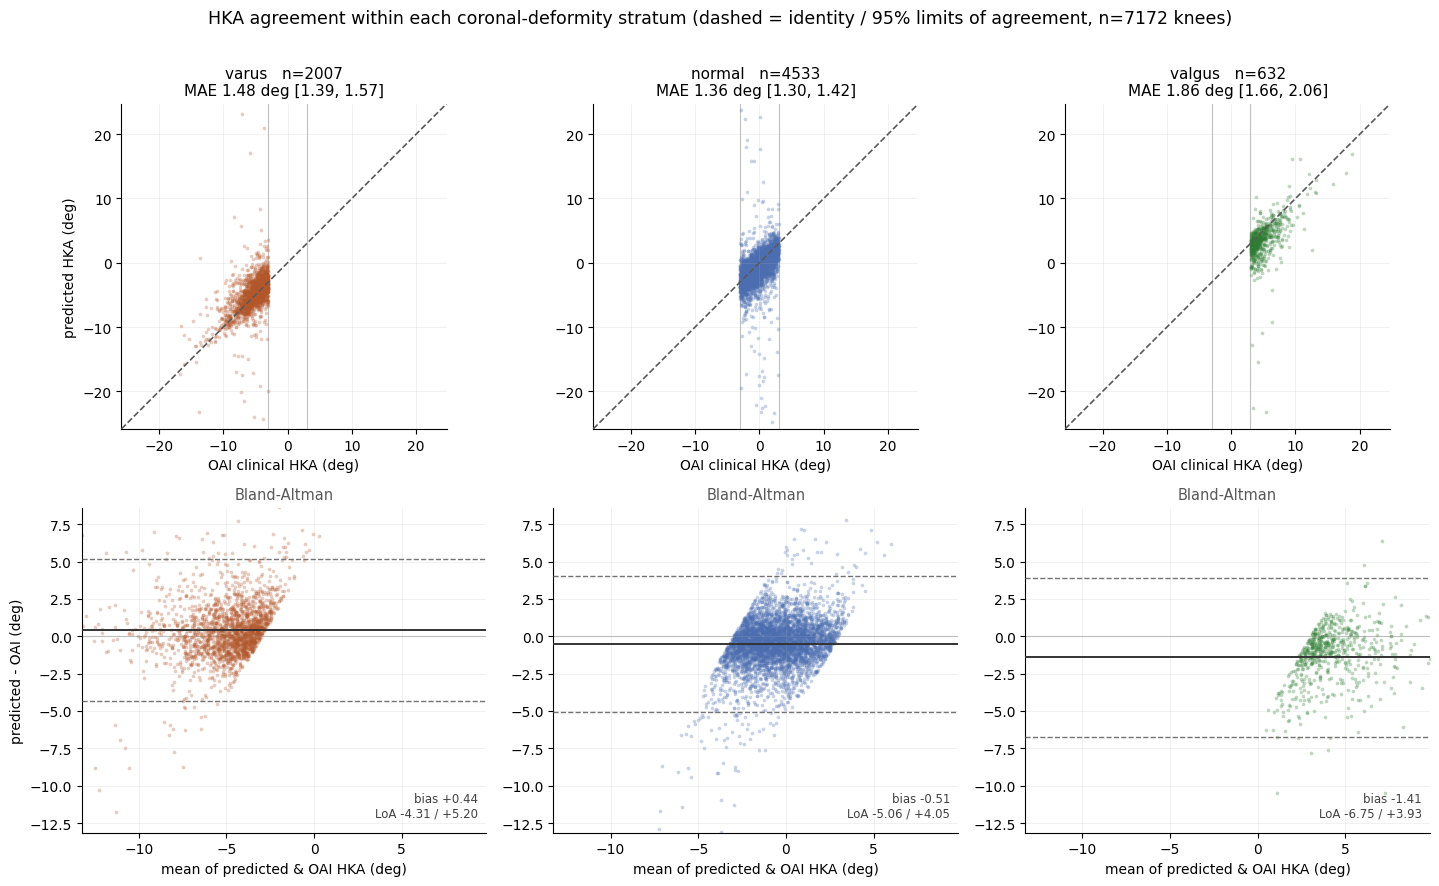

In [13]:
def _panel_scatter(ax, s, c):
    ax.scatter(s["oai_hka"], s["pred_hka"], s=7, alpha=0.30, color=PALETTE[c],
               linewidths=0, rasterized=True)
    lo, hi = XY_LIM
    ax.plot([lo, hi], [lo, hi], color="0.35", ls="--", lw=1.2, zorder=3)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal", adjustable="box")
    for cut in (NEUTRAL - NEUTRAL_BAND, NEUTRAL + NEUTRAL_BAND):
        ax.axvline(cut, color="0.75", lw=0.8, zorder=0)
    ax.set_xlabel("OAI clinical HKA (deg)")
    ax.grid(alpha=0.2, lw=0.6); ax.spines[["top", "right"]].set_visible(False)


def _panel_ba(ax, s, c, row):
    m = (s["pred_hka"] + s["oai_hka"]) / 2
    d = s["signed_err"]
    ax.scatter(m, d, s=7, alpha=0.30, color=PALETTE[c], linewidths=0, rasterized=True)
    ax.axhline(0, color="0.75", lw=0.8, zorder=0)
    ax.axhline(row["bias"],   color="0.20", lw=1.4, zorder=3)
    ax.axhline(row["loa_lo"], color="0.45", lw=1.0, ls="--", zorder=3)
    ax.axhline(row["loa_hi"], color="0.45", lw=1.0, ls="--", zorder=3)
    ax.set_xlim(*BA_XLIM); ax.set_ylim(*BA_LIM)
    ax.text(0.98, 0.04, f"bias {row['bias']:+.2f}\nLoA {row['loa_lo']:+.2f} / {row['loa_hi']:+.2f}",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5, color="0.25")
    ax.set_xlabel("mean of predicted & OAI HKA (deg)")
    ax.grid(alpha=0.2, lw=0.6); ax.spines[["top", "right"]].set_visible(False)


pad    = 1.0
XY_LIM = (float(min(A["oai_hka"].min(), A["pred_hka"].min())) - pad,
          float(max(A["oai_hka"].max(), A["pred_hka"].max())) + pad)

def _padded(v, q=(0.5, 99.5), frac=0.10):
    lo, hi = np.percentile(v, q); m = frac * (hi - lo)
    return (float(lo - m), float(hi + m))

BA_LIM  = _padded(A["signed_err"])                                   # shared across panels
BA_XLIM = _padded((A["pred_hka"] + A["oai_hka"]) / 2)                # so the shift is visible

fig, axes = plt.subplots(2, 3, figsize=(14.5, 9))
for j, c in enumerate(CLASSES):
    s = A[A["deformity"] == c]
    row = AG.loc[c]
    _panel_scatter(axes[0, j], s, c)
    axes[0, j].set_title(f"{c}   n={int(row['n'])}\nMAE {row['mae']:.2f} deg "
                         f"[{row['mae_lo']:.2f}, {row['mae_hi']:.2f}]", fontsize=11)
    _panel_ba(axes[1, j], s, c, row)
    axes[1, j].set_title("Bland-Altman", fontsize=10.5, color="0.35")
axes[0, 0].set_ylabel("predicted HKA (deg)")
axes[1, 0].set_ylabel("predicted - OAI (deg)")
fig.suptitle("HKA agreement within each coronal-deformity stratum "
             f"(dashed = identity / 95% limits of agreement, n={len(A)} knees)", fontsize=12.5)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.savefig(os.path.join(OUT_DIR, "stratum_agreement_panels.png"), dpi=150, bbox_inches="tight")
plt.show()

## 14 · Effect Sizes at a Glance

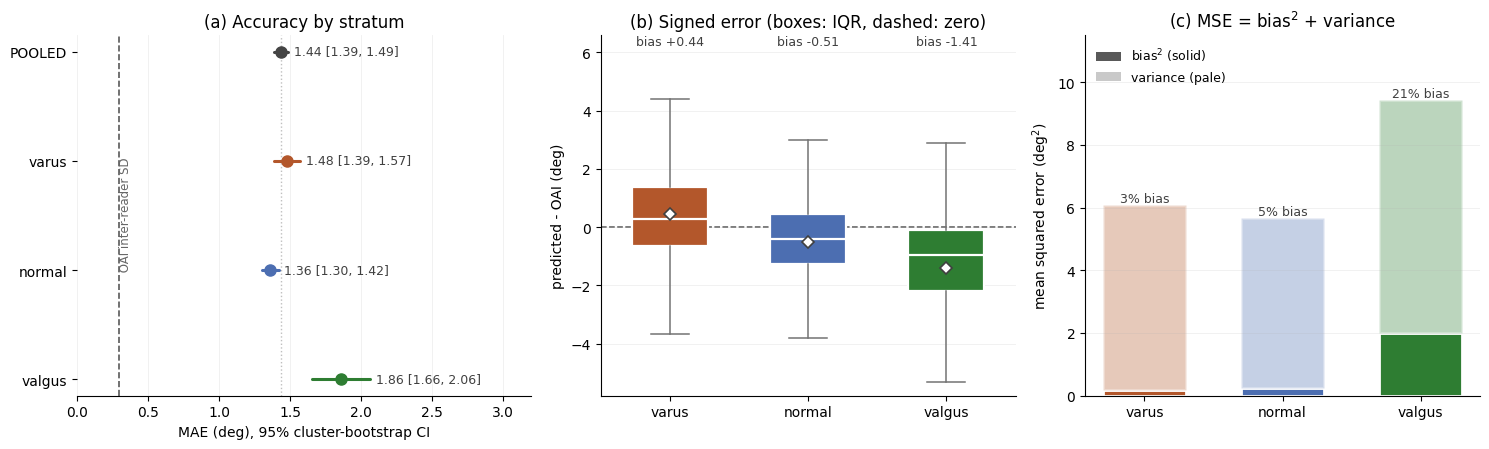

In [14]:
fig, (axF, axD, axB) = plt.subplots(1, 3, figsize=(15, 4.6),
                                    gridspec_kw={"width_ratios": [1.15, 1.05, 1.0]})

# --- (a) MAE forest, pooled + strata, with cluster-bootstrap CIs ---
names = ["POOLED"] + list(CLASSES)
ypos  = np.arange(len(names))[::-1]
for y, nm in zip(ypos, names):
    s = AG.loc[nm]
    axF.plot([s["mae_lo"], s["mae_hi"]], [y, y], color=PALETTE[nm], lw=2.2, solid_capstyle="round")
    axF.plot([s["mae"]], [y], "o", color=PALETTE[nm], ms=8, zorder=3)
    axF.text(s["mae_hi"] + 0.04, y, f"{s['mae']:.2f} [{s['mae_lo']:.2f}, {s['mae_hi']:.2f}]",
             va="center", fontsize=9, color="0.25")
axF.axvline(AG.loc["POOLED", "mae"], color="0.75", lw=1, ls=":", zorder=0)
if np.isfinite(oai_reader_sd):
    axF.axvline(oai_reader_sd, color="0.35", lw=1.2, ls="--", zorder=0)
    axF.text(oai_reader_sd, 0.5, " OAI inter-reader SD", fontsize=8.5, color="0.40",
             rotation=90, ha="left", va="center", transform=axF.get_xaxis_transform())
axF.set_yticks(ypos); axF.set_yticklabels(names)
axF.set_xlim(0, float(AG["mae_hi"].max()) * 1.55)
axF.set_xlabel("MAE (deg), 95% cluster-bootstrap CI")
axF.set_title("(a) Accuracy by stratum"); axF.grid(axis="x", alpha=0.2, lw=0.6)
axF.spines[["top", "right", "left"]].set_visible(False)

# --- (b) signed-error distribution: where the bias lives ---
data = [A.loc[A["deformity"] == c, "signed_err"].to_numpy(float) for c in CLASSES]
bp = axD.boxplot(data, vert=True, patch_artist=True, widths=0.55, showfliers=False,
                 medianprops=dict(color="white", lw=1.6),
                 whiskerprops=dict(color="0.45", lw=1.1), capprops=dict(color="0.45", lw=1.1))
for patch, c in zip(bp["boxes"], CLASSES):
    patch.set_facecolor(PALETTE[c]); patch.set_edgecolor("white"); patch.set_linewidth(1.6)
axD.axhline(0, color="0.35", lw=1.1, ls="--", zorder=0)
_ylo, _yhi = axD.get_ylim(); axD.set_ylim(_ylo, _yhi + 0.16 * (_yhi - _ylo))
for i, c in enumerate(CLASSES, start=1):
    b = AG.loc[c, "bias"]
    axD.plot([i], [b], marker="D", ms=6, color="white", mec="0.25", mew=1.2, zorder=4)
    axD.text(i, axD.get_ylim()[1], f"bias {b:+.2f}", fontsize=9, color="0.25",
             ha="center", va="top")
axD.set_xticks(range(1, len(CLASSES) + 1)); axD.set_xticklabels(CLASSES)
axD.set_ylabel("predicted - OAI (deg)")
axD.set_title("(b) Signed error (boxes: IQR, dashed: zero)")
axD.grid(axis="y", alpha=0.2, lw=0.6); axD.spines[["top", "right"]].set_visible(False)

# --- (c) is a stratum worse from bias or from scatter? ---
w = 0.6
from matplotlib.patches import Patch
axB.bar(CLASSES, DECOMP["bias2"], width=w, color=[PALETTE[c] for c in CLASSES],
        edgecolor="white", linewidth=2)
axB.bar(CLASSES, DECOMP["variance"], width=w, bottom=DECOMP["bias2"],
        color=[PALETTE[c] for c in CLASSES], alpha=0.32, edgecolor="white", linewidth=2)
for i, r in DECOMP.iterrows():
    axB.text(i, r["mse"], f"{r['bias_share']:.0f}% bias", ha="center", va="bottom",
             fontsize=9, color="0.25")
axB.set_ylabel("mean squared error (deg$^2$)")
axB.set_ylim(0, DECOMP["mse"].max() * 1.22)
axB.set_title("(c) MSE = bias$^2$ + variance")
axB.legend(handles=[Patch(facecolor="0.35", label="bias$^2$ (solid)"),
                    Patch(facecolor="0.35", alpha=0.32, label="variance (pale)")],
           frameon=False, fontsize=9, loc="upper left")
axB.grid(axis="y", alpha=0.2, lw=0.6); axB.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "stratum_effect_sizes.png"), dpi=150, bbox_inches="tight")
plt.show()

## 15 · How Much of Each Stratum's Error Is a Fixed Offset?

Section 12 split MSE into bias² and variance. This section puts that on the MAE scale by asking a
counterfactual: **if the model's systematic offset were removed, how much error would be left?**

Two removals, and the difference between them is the point:

- **global** — subtract one constant, the pooled bias, from every prediction. Deployable: it is a
  single number learned once on the whole cohort.
- **oracle** — subtract each stratum's *own* mean bias. Not deployable (you would have to know the
  answer to pick the constant), but it is the ceiling on what any pure-offset correction can buy,
  and what is left over is the stratum's genuine localisation floor.

A stratum where the global removal already captures most of the oracle gain is uniformly offset. A
stratum where only the oracle removal helps is offset *differently from the rest of the cohort* —
the signature of the compression found in section 12, which pulls the far strata hardest.

Read this together with `TRAIN_DOMAIN`: an offset correction fitted on one cohort is only
transportable within the domain it was fitted on. For a stratum the model never trained on, a
"correction" estimated from this validation set is a description of *this* cohort, not a
deployable calibration.

> A regression-based recalibration is deliberately not used here. Fitting predicted-on-true and
> inverting it is circular, and fitting true-on-predicted is an ordinary least-squares predictor
> that shrinks the tails *further* — it lowers squared error while making the extreme strata worse,
> which is the opposite of the question being asked.

In [15]:
pooled_bias = float(A["signed_err"].mean())

cal_rows = []
for nm in ["POOLED"] + list(CLASSES):
    sub = A if nm == "POOLED" else A[A["deformity"] == nm]
    e = sub["signed_err"].to_numpy(float)
    cal_rows.append(dict(subset=nm, n=len(e), bias=e.mean(), sd=e.std(ddof=1),
                         mae_raw=np.abs(e).mean(),
                         mae_global=np.abs(e - pooled_bias).mean(),
                         mae_oracle=np.abs(e - e.mean()).mean()))
CAL = pd.DataFrame(cal_rows).set_index("subset")
CAL["gain_global_pct"] = 100 * (CAL["mae_raw"] - CAL["mae_global"]) / CAL["mae_raw"]
CAL["gain_oracle_pct"] = 100 * (CAL["mae_raw"] - CAL["mae_oracle"]) / CAL["mae_raw"]

print("=" * 96)
print(f"OFFSET-REMOVAL COUNTERFACTUAL   (global constant = pooled bias {pooled_bias:+.3f} deg)")
print("=" * 96)
print(f"  {'subset':8s} {'bias':>8s} {'MAE raw':>9s} {'MAE -global':>12s} {'gain':>7s} "
      f"{'MAE -own bias':>14s} {'gain':>7s}")
for nm, s_ in CAL.iterrows():
    print(f"  {nm:8s} {s_['bias']:+8.3f} {s_['mae_raw']:9.3f} {s_['mae_global']:12.3f} "
          f"{s_['gain_global_pct']:6.1f}% {s_['mae_oracle']:14.3f} {s_['gain_oracle_pct']:6.1f}%")

strata = list(CLASSES)
gap_raw = CAL.loc[strata, "mae_raw"].max()    - CAL.loc[strata, "mae_raw"].min()
gap_glb = CAL.loc[strata, "mae_global"].max() - CAL.loc[strata, "mae_global"].min()
gap_orc = CAL.loc[strata, "mae_oracle"].max() - CAL.loc[strata, "mae_oracle"].min()
print(f"\n  Spread between the best and worst stratum:")
print(f"     {gap_raw:.3f} deg as measured")
print(f"     {gap_glb:.3f} deg after one global constant   "
      f"({100 * (gap_raw - gap_glb) / gap_raw:+.0f}% of the spread)")
print(f"     {gap_orc:.3f} deg after each stratum's own offset  "
      f"({100 * (gap_raw - gap_orc) / gap_raw:+.0f}% of the spread)")
worst = CAL.loc[strata, "mae_oracle"].idxmax()
print(f"\n  Residual floor: with every offset removed the worst stratum is still '{worst}' at "
      f"{CAL.loc[worst, 'mae_oracle']:.3f} deg.")
print(f"  That residual is scatter in the landmarks themselves — no post-hoc offset reaches it.")
print("  The oracle column is a ceiling, not a result: it uses the answer to choose the constant.")
print("=" * 96)

OFFSET-REMOVAL COUNTERFACTUAL   (global constant = pooled bias -0.320 deg)
  subset       bias   MAE raw  MAE -global    gain  MAE -own bias    gain
  POOLED     -0.320     1.436        1.413    1.6%          1.413    1.6%
  varus      +0.444     1.476        1.554   -5.3%          1.463    0.9%
  normal     -0.505     1.360        1.309    3.7%          1.309    3.7%
  valgus     -1.412     1.859        1.709    8.1%          1.635   12.1%

  Spread between the best and worst stratum:
     0.499 deg as measured
     0.400 deg after one global constant   (+20% of the spread)
     0.326 deg after each stratum's own offset  (+35% of the spread)

  Residual floor: with every offset removed the worst stratum is still 'valgus' at 1.635 deg.
  That residual is scatter in the landmarks themselves — no post-hoc offset reaches it.
  The oracle column is a ceiling, not a result: it uses the answer to choose the constant.


## 16 · Triage — Does the Model Assign the Right Deformity?

Agreement in degrees is the measurement question. The clinical question is coarser: shown a new
radiograph, does the model put the knee in the right alignment class? Predicted class comes from
the predicted HKA under exactly the same rule used on ground truth, so the confusion matrix is a
fair like-for-like.

The **varus row matters most** — those are the HTO candidates a screening use of this model would
be expected to surface.

DEFORMITY TRIAGE   (band +/-3.0 deg, n=7172 analysed knees)

  confusion matrix — rows: OAI ground truth, columns: model
            pred varus  pred normal  pred valgus
OAI varus         1621          377            9
OAI normal         612         3773          148
OAI valgus           7          237          388

deformity    n  sens  spec  ppv  npv   f1
    varus 2007  80.8  88.0 72.4 92.2 76.3
   normal 4533  83.2  76.7 86.0 72.7 84.6
   valgus  632  61.4  97.6 71.2 96.3 65.9

  accuracy 80.6%   balanced accuracy 75.1%   Cohen's kappa 0.627   linear-weighted kappa 0.655
  counting the 475 flagged failures as misclassifications: balanced accuracy 70.5%
  varus<->valgus confusions (a sign-level error): 16 of 7172 (0.22%) — near zero means the geometry is sound and the misses are borderline knees, not flipped legs.

  Continuous discrimination (predicted HKA as a score, threshold-free):
     AUC varus vs rest  = 0.915
     AUC valgus vs rest = 0.938


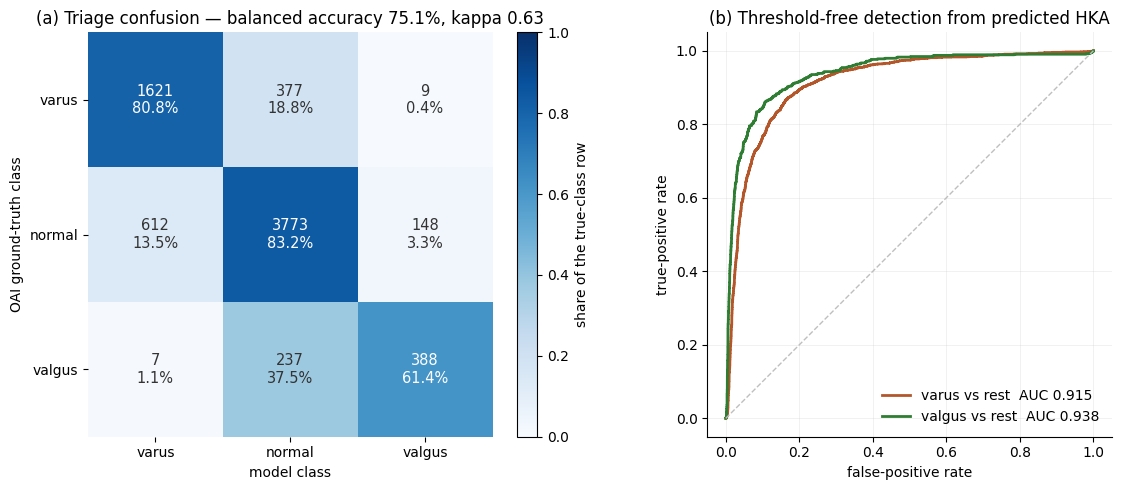

In [16]:
from scipy.stats import rankdata

A_t = A.copy()
A_t["pred_deformity"] = [classify(v) for v in A_t["pred_hka"]]

def confusion(true_cls, pred_cls, classes=CLASSES):
    ix = {c: i for i, c in enumerate(classes)}
    C  = np.zeros((len(classes), len(classes)), int)
    for t, p in zip(true_cls, pred_cls):
        C[ix[t], ix[p]] += 1
    return C

def class_metrics(C, classes=CLASSES):
    N = C.sum(); out = []
    for i, c in enumerate(classes):
        tp = C[i, i]; fn = C[i, :].sum() - tp; fp = C[:, i].sum() - tp; tn = N - tp - fn - fp
        out.append(dict(deformity=c, n=int(C[i, :].sum()),
                        sens=tp / (tp + fn) if tp + fn else np.nan,
                        spec=tn / (tn + fp) if tn + fp else np.nan,
                        ppv=tp / (tp + fp) if tp + fp else np.nan,
                        npv=tn / (tn + fn) if tn + fn else np.nan,
                        f1=2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) else np.nan))
    return pd.DataFrame(out)

def kappa(C, weights="unweighted"):
    C = np.asarray(C, float); N = C.sum(); k = C.shape[0]
    po = C / N; pe = np.outer(C.sum(1), C.sum(0)) / N ** 2
    if weights == "unweighted":
        W = 1.0 - np.eye(k)
    elif weights == "linear":
        W = np.abs(np.subtract.outer(np.arange(k), np.arange(k))) / (k - 1)
    else:
        W = np.subtract.outer(np.arange(k), np.arange(k)) ** 2 / (k - 1) ** 2
    return 1 - (W * po).sum() / (W * pe).sum()

def auc_rank(score, label):
    """AUC via the Mann-Whitney rank identity (handles ties exactly)."""
    score = np.asarray(score, float); label = np.asarray(label, bool)
    n1 = int(label.sum()); n0 = int((~label).sum())
    if n1 == 0 or n0 == 0:
        return np.nan
    r = rankdata(score)
    return (r[label].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

def roc_curve(score, label):
    score = np.asarray(score, float); label = np.asarray(label, bool)
    o = np.argsort(-score); y = label[o]
    tp = np.cumsum(y); fp = np.cumsum(~y)
    return np.r_[0, fp / max(fp[-1], 1)], np.r_[0, tp / max(tp[-1], 1)]

CM  = confusion(A_t["deformity"], A_t["pred_deformity"])
TRI = class_metrics(CM)
acc, bal = np.trace(CM) / CM.sum(), TRI["sens"].mean()
k_un, k_lin = kappa(CM), kappa(CM, "linear")

# a failed knee is a missed classification in deployment, so report that variant too
n_flag = int(R["flagged"].sum())
bal_incl = float(np.mean([
    (CM[i, i]) / max(int((R["deformity"] == c).sum()), 1) for i, c in enumerate(CLASSES)]))

print("=" * 88)
print(f"DEFORMITY TRIAGE   (band +/-{NEUTRAL_BAND:.1f} deg, n={CM.sum()} analysed knees)")
print("=" * 88)
print("\n  confusion matrix — rows: OAI ground truth, columns: model")
print(pd.DataFrame(CM, index=[f"OAI {c}" for c in CLASSES],
                   columns=[f"pred {c}" for c in CLASSES]).to_string())
print()
print(TRI.assign(**{k: (TRI[k] * 100).round(1) for k in ("sens", "spec", "ppv", "npv", "f1")})
        .to_string(index=False))
print(f"\n  accuracy {100*acc:.1f}%   balanced accuracy {100*bal:.1f}%   "
      f"Cohen's kappa {k_un:.3f}   linear-weighted kappa {k_lin:.3f}")
print(f"  counting the {n_flag} flagged failures as misclassifications: "
      f"balanced accuracy {100*bal_incl:.1f}%")

adj = CM[0, 2] + CM[2, 0]
print(f"  varus<->valgus confusions (a sign-level error): {adj} of {CM.sum()} "
      f"({100*adj/CM.sum():.2f}%) — near zero means the geometry is sound and the misses are "
      f"borderline knees, not flipped legs.")

auc_v = auc_rank(-A_t["pred_hka"].to_numpy(float), (A_t["deformity"] == "varus").to_numpy())
auc_g = auc_rank( A_t["pred_hka"].to_numpy(float), (A_t["deformity"] == "valgus").to_numpy())
print(f"\n  Continuous discrimination (predicted HKA as a score, threshold-free):")
print(f"     AUC varus vs rest  = {auc_v:.3f}")
print(f"     AUC valgus vs rest = {auc_g:.3f}")
print("=" * 88)

# ---------------- figure ----------------
fig, (axC, axR) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.15, 1]})
rown = CM.sum(1, keepdims=True).clip(min=1)
im = axC.imshow(CM / rown, cmap="Blues", vmin=0, vmax=1)          # sequential, one hue
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        frac = CM[i, j] / rown[i, 0]
        axC.text(j, i, f"{CM[i, j]}\n{100*frac:.1f}%", ha="center", va="center", fontsize=10.5,
                 color="white" if frac > 0.55 else "0.20")
axC.set_xticks(range(len(CLASSES)), CLASSES); axC.set_yticks(range(len(CLASSES)), CLASSES)
axC.set_xlabel("model class"); axC.set_ylabel("OAI ground-truth class")
axC.set_title(f"(a) Triage confusion — balanced accuracy {100*bal:.1f}%, kappa {k_un:.2f}")
axC.spines[:].set_visible(False)
plt.colorbar(im, ax=axC, fraction=0.046, pad=0.04, label="share of the true-class row")

for c, sc, lab, au in ((("varus"), -A_t["pred_hka"].to_numpy(float), "varus vs rest", auc_v),
                       (("valgus"), A_t["pred_hka"].to_numpy(float), "valgus vs rest", auc_g)):
    fpr, tpr = roc_curve(sc, (A_t["deformity"] == c).to_numpy())
    axR.plot(fpr, tpr, color=PALETTE[c], lw=2, label=f"{lab}  AUC {au:.3f}")
axR.plot([0, 1], [0, 1], color="0.75", lw=1, ls="--")
axR.set_xlabel("false-positive rate"); axR.set_ylabel("true-positive rate")
axR.set_title("(b) Threshold-free detection from predicted HKA")
axR.legend(frameon=False, loc="lower right"); axR.grid(alpha=0.2, lw=0.6)
axR.spines[["top", "right"]].set_visible(False); axR.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "triage_performance.png"), dpi=150, bbox_inches="tight")
plt.show()

## 17 · Threshold Sensitivity

`NEUTRAL_BAND = 3°` is a convention, not a fact. Everything above is re-run across bands 1–5° so
you can see which conclusions survive the choice and which are artefacts of it. A finding that
flips between 2° and 4° should not be reported without the band attached.

   band                   varus                  normal                  valgus   bal.acc  kappa
             n (%)   MAE   bias      n (%)   MAE   bias      n (%)   MAE   bias
    1.0   3743 (52.2)  1.37 +0.17   1706 (23.8)  1.40 -0.62   1723 (24.0)  1.61 -1.09     0.683  0.569
    2.0   2853 (39.8)  1.43 +0.30   3232 (45.1)  1.35 -0.56   1087 (15.2)  1.73 -1.25     0.739  0.608
    3.0   2007 (28.0)  1.48 +0.44   4533 (63.2)  1.36 -0.51    632 ( 8.8)  1.86 -1.41     0.751  0.627
    4.0   1376 (19.2)  1.60 +0.63   5419 (75.6)  1.35 -0.47    377 ( 5.3)  2.12 -1.68     0.734  0.617
    5.0    883 (12.3)  1.75 +0.84   6069 (84.6)  1.36 -0.43    220 ( 3.1)  2.27 -1.88     0.718  0.592


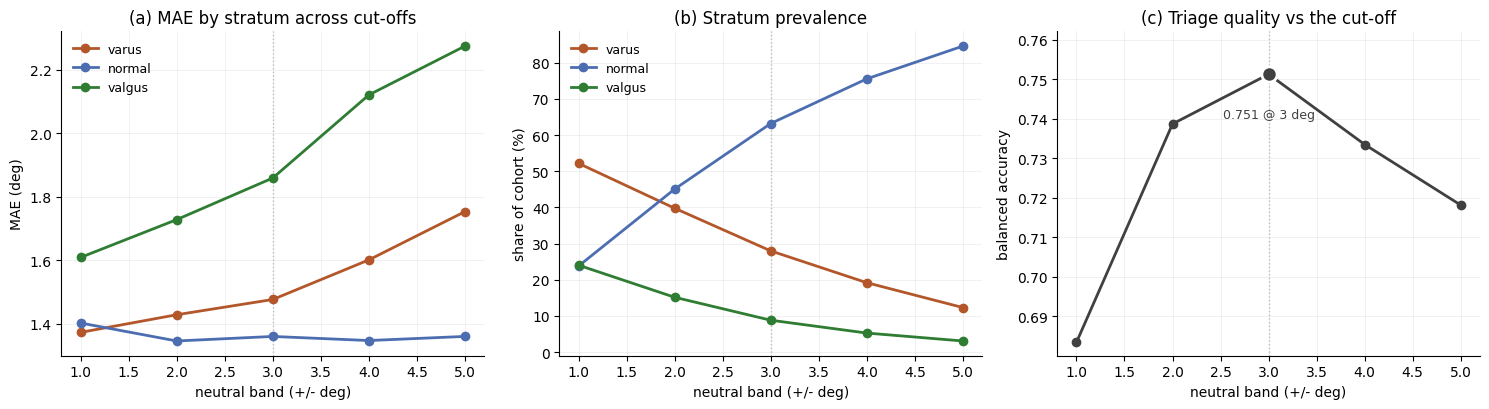

In [17]:
sweep_rows = []
for band in BAND_SWEEP:
    true_c = np.array([classify(v, band=band) for v in A["oai_hka"]])
    pred_c = np.array([classify(v, band=band) for v in A["pred_hka"]])
    Cb = confusion(true_c, pred_c); mb = class_metrics(Cb)
    for c in CLASSES:
        m = true_c == c
        sweep_rows.append(dict(
            band=band, deformity=c, n=int(m.sum()), pct=100 * m.mean(),
            mae=float(A.loc[m, "abs_err"].mean()) if m.any() else np.nan,
            bias=float(A.loc[m, "signed_err"].mean()) if m.any() else np.nan,
            sens=float(mb.loc[mb["deformity"] == c, "sens"].iloc[0]),
            bal_acc=float(mb["sens"].mean()), kappa=kappa(Cb)))
SWEEP = pd.DataFrame(sweep_rows)

print(f"  {'band':>5s}  " + "  ".join(f"{c:>22s}" for c in CLASSES) + f"  {'bal.acc':>8s} {'kappa':>6s}")
print(f"  {'':>5s}  " + "  ".join(f"{'n (%)   MAE   bias':>22s}" for _ in CLASSES))
for band in BAND_SWEEP:
    g = SWEEP[SWEEP["band"] == band].set_index("deformity")
    cells = "  ".join(f"{int(g.loc[c,'n']):5d} ({g.loc[c,'pct']:4.1f}) {g.loc[c,'mae']:5.2f} "
                      f"{g.loc[c,'bias']:+5.2f}" for c in CLASSES)
    print(f"  {band:5.1f}  {cells}  {g['bal_acc'].iloc[0]:8.3f} {g['kappa'].iloc[0]:6.3f}")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.2))
for c in CLASSES:
    g = SWEEP[SWEEP["deformity"] == c]
    ax1.plot(g["band"], g["mae"], "-o", color=PALETTE[c], lw=2, ms=6, label=c)
    ax2.plot(g["band"], g["pct"], "-o", color=PALETTE[c], lw=2, ms=6, label=c)
for ax, ylab, ttl in ((ax1, "MAE (deg)", "(a) MAE by stratum across cut-offs"),
                      (ax2, "share of cohort (%)", "(b) Stratum prevalence")):
    ax.axvline(NEUTRAL_BAND, color="0.75", lw=1, ls=":", zorder=0)
    ax.set_xlabel("neutral band (+/- deg)"); ax.set_ylabel(ylab); ax.set_title(ttl)
    ax.legend(frameon=False, fontsize=9); ax.grid(alpha=0.2, lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)

g = SWEEP.drop_duplicates("band")
ax3.plot(g["band"], g["bal_acc"], "-o", color="0.25", lw=2, ms=6)
best = g.loc[g["bal_acc"].idxmax()]
ax3.plot([best["band"]], [best["bal_acc"]], "o", color="0.25", ms=11,
         mec="white", mew=2, zorder=3)
_lo, _hi = ax3.get_ylim(); ax3.set_ylim(_lo, _hi + 0.10 * (_hi - _lo))
ax3.annotate(f"{best['bal_acc']:.3f} @ {best['band']:.0f} deg",
             xy=(best["band"], best["bal_acc"]), xytext=(0, -24),
             textcoords="offset points", ha="center", va="top",
             fontsize=9, color="0.25")
ax3.axvline(NEUTRAL_BAND, color="0.75", lw=1, ls=":", zorder=0)
ax3.set_xlabel("neutral band (+/- deg)"); ax3.set_ylabel("balanced accuracy")
ax3.set_title("(c) Triage quality vs the cut-off"); ax3.grid(alpha=0.2, lw=0.6)
ax3.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "band_sensitivity.png"), dpi=150, bbox_inches="tight")
plt.show()

## 18 · Optional — Materialise the Subsets on Disk

Off by default: the analysis above never needs it. Turn `MATERIALISE_SUBSETS = True` on only when
another tool wants three standalone folders. Source images are read, never written — the cell
fingerprints `OAI_IMAGE_DIR` before and after and fails if anything there changed. Each subset
gets a ground-truth CSV in the source schema with the off-class knee blanked, so it is a drop-in
for the pooled validation notebook.

In [18]:
if not MATERIALISE_SUBSETS:
    print("MATERIALISE_SUBSETS = False — skipped (the analysis does not depend on it).")
else:
    def dir_fingerprint(d):
        out = {}
        for p in glob.glob(os.path.join(d, "*")):
            if os.path.splitext(p)[1].lower() in IMG_EXTS and os.path.isfile(p):
                st = os.stat(p); out[os.path.basename(p)] = (st.st_size, int(st.st_mtime))
        return out

    before = dir_fingerprint(OAI_IMAGE_DIR)

    def place(src, dst):
        if os.path.exists(dst) or os.path.islink(dst):
            return "skipped"
        tmp = dst + ".part"
        if COPY_MODE == "copy":     shutil.copy2(src, tmp)
        elif COPY_MODE == "hardlink": os.link(src, tmp)
        else:                       os.symlink(os.path.abspath(src), tmp)
        os.replace(tmp, dst)
        return "written"

    n_written = n_skipped = n_missing = 0
    for c in CLASSES:
        d = os.path.join(SUBSET_ROOT, c); os.makedirs(d, exist_ok=True)
        members = knee_manifest[knee_manifest["deformity"] == c]
        for bc in sorted(set(members["barcode"])):
            src = src_index.get(bc)
            if src is None:
                n_missing += 1; continue
            st = place(src, os.path.join(d, os.path.basename(src)))
            n_written += st == "written"; n_skipped += st == "skipped"

        sub = hka_df[hka_df[HKA_KEY_COL].isin(set(members["barcode"]))].copy()
        keep = {(b, s) for b, s in zip(members["barcode"], members["side"])}
        for side, hcol in (("1", HKA_SIDE1_COL), ("2", HKA_SIDE2_COL)):
            off = ~sub[HKA_KEY_COL].map(lambda b, s=side: (b, s) in keep)
            for col in (hcol, f"nread_side{side}", f"readsd_side{side}"):
                if col in sub.columns:
                    sub.loc[off, col] = np.nan
        sub.to_csv(os.path.join(d, "oai_hka_groundtruth.csv"), index=False)
        print(f"  {c:7s} -> {d}   {len(sub):5d} images / "
              f"{int(sub[[HKA_SIDE1_COL, HKA_SIDE2_COL]].notna().sum().sum()):5d} knees")

    after = dir_fingerprint(OAI_IMAGE_DIR)
    assert after == before, "SOURCE DIRECTORY CHANGED — this cell must only ever read it"
    print(f"\n{n_written} written, {n_skipped} already present, {n_missing} without an image file.")
    print(f"Source directory verified unchanged ({len(before)} files).")

MATERIALISE_SUBSETS = False — skipped (the analysis does not depend on it).


## 19 · Exports

In [19]:
exports = {
    "knee_results.csv":       R,
    "stratum_agreement.csv":  AG.reset_index(),
    "stratum_contrasts.csv":  CONTRASTS,
    "error_decomposition.csv": DECOMP,
    "bias_mechanism.csv":     MECH,
    "calibration.csv":        CAL.reset_index(),
    "triage_metrics.csv":     TRI,
    "confusion_matrix.csv":   pd.DataFrame(CM, index=list(CLASSES), columns=list(CLASSES)),
    "band_sweep.csv":         SWEEP,
    "cohort_composition.csv": cohort,
}
for fn, df in exports.items():
    df.to_csv(os.path.join(OUT_DIR, fn), index=(fn == "confusion_matrix.csv"))

headline = dict(
    generated=pd.Timestamp.now().isoformat(timespec="seconds"),
    checkpoint=CHECKPOINT_PATH, model_variant=MODEL_VARIANT,
    neutral_band_deg=NEUTRAL_BAND, exclude_abs_dev_deg=EXCLUDE_ABS_DEV,
    cluster_unit=CLUSTER_COL, n_boot=N_BOOT,
    knees_total=int(len(R)), knees_analysed=int(len(A)),
    failure_pct=float(100 * R["flagged"].mean()),
    oai_inter_reader_sd=None if not np.isfinite(oai_reader_sd) else round(float(oai_reader_sd), 3),
    train_domain=TRAIN_DOMAIN,
    compression=dict(intercept=round(float(intercept), 4), lam=round(float(LAMBDA), 4),
                     fixed_point=round(float(FIXED_PT), 3)),
    per_stratum={nm: dict(domain=str(s["domain"]), n=int(s["n"]), mae=round(float(s["mae"]), 3),
                          mae_ci=[round(float(s["mae_lo"]), 3), round(float(s["mae_hi"]), 3)],
                          bias=round(float(s["bias"]), 3),
                          loa=[round(float(s["loa_lo"]), 2), round(float(s["loa_hi"]), 2)],
                          icc=round(float(s["icc"]), 3),
                          failure_pct=round(float(s["failure_pct"]), 2))
                 for nm, s in AG.iterrows()},
    triage=dict(accuracy=round(float(acc), 4), balanced_accuracy=round(float(bal), 4),
                kappa=round(float(k_un), 4), kappa_linear=round(float(k_lin), 4),
                auc_varus=round(float(auc_v), 4), auc_valgus=round(float(auc_g), 4)),
    proportional_bias_slope=[round(float(slope), 4), round(float(sl_lo), 4), round(float(sl_hi), 4)],
)
with open(os.path.join(OUT_DIR, "summary.json"), "w") as f:
    json.dump(headline, f, indent=2)

print(f"Wrote {len(exports) + 1} files + 4 figures to {os.path.abspath(OUT_DIR)}:")
for fn in list(exports) + ["summary.json"]:
    print(f"  {fn}")

Wrote 11 files + 4 figures to /tf/notebooks/oai_deformity_stratified:
  knee_results.csv
  stratum_agreement.csv
  stratum_contrasts.csv
  error_decomposition.csv
  bias_mechanism.csv
  calibration.csv
  triage_metrics.csv
  confusion_matrix.csv
  band_sweep.csv
  cohort_composition.csv
  summary.json


## 20 · Verification

Fails loudly if anything above is internally inconsistent — strata that do not partition the
cohort, labels that disagree with the rule, metrics that cannot be recovered from the raw errors,
confidence intervals that miss their own point estimate, or a confusion matrix that does not
account for every analysed knee.

In [20]:
problems = []

def check(cond, msg):
    if not cond:
        problems.append(msg)

# --- 1. the strata partition the cohort exactly once ---
check(len(R) == R[["barcode", "side"]].drop_duplicates().shape[0], "a knee appears twice in R")
check(int(R.groupby("deformity", observed=False).size().sum()) == len(R),
      "stratum sizes do not sum to the knee count")
check(R["deformity"].isna().sum() == 0, "a knee has no stratum")
check(set(R["deformity"].dropna().unique()) <= set(CLASSES), "an unexpected stratum label appeared")

# --- 2. labels really follow the rule, recomputed from the raw HKA ---
check(all(classify(h) == d for h, d in zip(R["oai_hka"], R["deformity"])),
      "a stratum label disagrees with classify()")
check(all(v <  NEUTRAL - NEUTRAL_BAND for v in R.loc[R["deformity"] == "varus",  "oai_hka"]),
      "a varus knee is inside the neutral band")
check(all(v >  NEUTRAL + NEUTRAL_BAND for v in R.loc[R["deformity"] == "valgus", "oai_hka"]),
      "a valgus knee is inside the neutral band")
check(all(abs(v - NEUTRAL) <= NEUTRAL_BAND for v in R.loc[R["deformity"] == "normal", "oai_hka"]),
      "a normal knee is outside the neutral band")

# --- 3. strata are model-independent: they must equal the labels fixed before inference ---
_mf = knee_manifest[["barcode", "side", "deformity", "oai_hka"]].rename(
    columns={"deformity": "deformity_pre", "oai_hka": "oai_hka_pre"})
_j = R[["barcode", "side", "deformity", "oai_hka"]].merge(_mf, on=["barcode", "side"], how="left")
check(len(_j) == len(R) and _j["deformity_pre"].notna().all(),
      "a scored knee is missing from the pre-inference manifest")
check(bool((_j["deformity"].astype(str) == _j["deformity_pre"].astype(str)).all()),
      "a stratum label changed between the manifest and the results table")
check(bool(np.allclose(_j["oai_hka"], _j["oai_hka_pre"])),
      "ground-truth HKA changed between the manifest and the results table")
check("pred_hka" not in knee_manifest.columns,
      "the stratum definition has been contaminated by predictions")

# --- 4. reported metrics are recoverable from the raw per-knee errors ---
for nm in ["POOLED"] + list(CLASSES):
    sub = A if nm == "POOLED" else A[A["deformity"] == nm]
    s = AG.loc[nm]
    check(int(s["n"]) == len(sub), f"{nm}: reported n does not match the subset size")
    check(abs(s["mae"]  - sub["abs_err"].mean())    < 1e-9, f"{nm}: MAE not reproducible")
    check(abs(s["bias"] - sub["signed_err"].mean()) < 1e-9, f"{nm}: bias not reproducible")
    check(abs(s["rmse"] - np.sqrt((sub["signed_err"] ** 2).mean())) < 1e-9,
          f"{nm}: RMSE not reproducible")
    check(abs((s["loa_hi"] - s["loa_lo"]) - 2 * 1.96 * s["sd"]) < 1e-9, f"{nm}: LoA width wrong")
    check(np.isnan(s["mae_lo"]) or s["mae_lo"] <= s["mae"] <= s["mae_hi"],
          f"{nm}: bootstrap CI does not bracket the MAE")
    check(abs(s["mae"] - np.abs(sub["pred_hka"] - sub["oai_hka"]).mean()) < 1e-9,
          f"{nm}: MAE disagrees with a direct recomputation")

# pooled MAE must be the knee-weighted mean of the stratum MAEs
_pool = sum(AG.loc[c, "n"] * AG.loc[c, "mae"] for c in CLASSES) / sum(AG.loc[c, "n"] for c in CLASSES)
check(abs(_pool - AG.loc["POOLED", "mae"]) < 1e-9, "stratum MAEs do not aggregate to the pooled MAE")

# --- 5. exclusions are accounted for ---
check(len(A) + int(R["flagged"].sum()) == len(R), "analysed + flagged != total knees")
check(bool((np.abs(A["pred_hka"] - NEUTRAL) <= EXCLUDE_ABS_DEV).all()),
      "a flagged knee leaked into the analysed set")

# --- 6. triage internals ---
check(CM.sum() == len(A_t), "confusion matrix does not account for every analysed knee")
check(np.array_equal(CM.sum(1), np.array([int((A_t["deformity"] == c).sum()) for c in CLASSES])),
      "confusion-matrix rows do not match the true stratum sizes")
check(abs(bal - np.mean([CM[i, i] / max(CM[i, :].sum(), 1) for i in range(len(CLASSES))])) < 1e-12,
      "balanced accuracy is not the mean of per-class recalls")
check(abs(acc - np.trace(CM) / CM.sum()) < 1e-12, "accuracy does not match the confusion matrix")
check(-1.0 <= k_un <= 1.0 and -1.0 <= k_lin <= 1.0, "kappa outside [-1, 1]")
check(np.isnan(auc_v) or 0.0 <= auc_v <= 1.0, "AUC outside [0, 1]")

# --- 7. the sweep contains the reported band and reproduces it ---
if NEUTRAL_BAND in set(SWEEP["band"]):
    for c in CLASSES:
        row = SWEEP[(SWEEP["band"] == NEUTRAL_BAND) & (SWEEP["deformity"] == c)].iloc[0]
        check(int(row["n"]) == int(AG.loc[c, "n"]), f"sweep disagrees with section 11 on n[{c}]")
        check(abs(row["mae"] - AG.loc[c, "mae"]) < 1e-9,
              f"sweep disagrees with section 11 on MAE[{c}]")

print("=" * 78)
if problems:
    print(f"VERIFICATION FAILED — {len(problems)} problem(s):")
    for p in problems:
        print("  x", p)
else:
    print("VERIFICATION PASSED")
    print(f"  {len(R)} knees partitioned into {len(CLASSES)} strata, "
          f"{len(A)} analysed after {int(R['flagged'].sum())} flagged exclusions")
    print(f"  every reported metric reproduced from the raw per-knee errors")
    print(f"  {N_BOOT} cluster-bootstrap replicates over "
          f"{R[CLUSTER_COL].nunique()} {CLUSTER_COL}s, all CIs bracket their estimates")
print("=" * 78)
assert not problems, problems

VERIFICATION PASSED
  7647 knees partitioned into 3 strata, 7172 analysed after 475 flagged exclusions
  every reported metric reproduced from the raw per-knee errors
  2000 cluster-bootstrap replicates over 3740 subjs, all CIs bracket their estimates


## 21 · Reading These Results

**Compare MAE, bias and LoA across strata; do not compare ICC or *r*.** Within a stratum the true
HKA barely varies — the `normal` band spans 6° by construction — and every correlation-type
statistic is a ratio of between-subject to total variance. Restricting the range shrinks the
numerator and the statistic collapses even when the model's error is unchanged. The pooled ICC is
the honest one; the per-stratum ICC in the table is printed only so nobody recomputes it and
mistakes the drop for a finding.

**A stratum can be worse for two different reasons, and section 12 tells them apart.** A large
bias² share means the model is systematically off in that stratum — a calibration problem, often
shrinkage toward the cohort mean, and section 15 puts a ceiling on how much of it any offset
correction could remove. A large variance share means the landmarks themselves are harder to place
there, which no post-hoc correction reaches.

**Two of the three strata are extrapolation, and that reframes the whole result.** With an
HTO-candidate training cohort the model has seen varus legs and essentially nothing else, so
`varus` is the only stratum measured inside its training domain. `normal` and `valgus` are
zero-shot transfer to alignment the detector was never optimised for. That makes the varus
number the deployment-relevant one and the other two a domain-shift measurement — a stronger
claim than "subgroup analysis", and a more honest one. It also means the ordering to expect is
not "rare classes are harder" but "distance from the training domain costs accuracy", which
section 12 tests directly: if one global compression reproduces every stratum's bias from its
distance to the fixed point, there is no stratum-specific anatomical difficulty to invoke.

**Watch the smallest stratum.** Valgus is typically a few hundred knees in OAI against several
thousand normal ones, so its CI is correspondingly wide. Read the interval, not the point
estimate, and say so in the paper.

**Failure rate is a per-stratum result too.** A knee whose predicted HKA lands beyond
`EXCLUDE_ABS_DEV` is dropped from the agreement statistics, and if those failures cluster in one
stratum the remaining MAE there is optimistic. Section 11 prints the rate beside every stratum for
exactly that reason.

**The triage matrix answers a different question from MAE**, and it is the one a clinical reader
asks first. Off-by-one confusions (varus↔normal, normal↔valgus) are borderline knees near a
cut-off — largely a property of where the line was drawn, which is why section 17 exists.
Varus↔valgus confusions are different in kind: those are sign-level failures, and a non-trivial
count there means the laterality/sign configuration or the landmark geometry needs attention
before anything else in this notebook is worth reporting.

**What this validates and what it does not.** HKA uses the femoral head, knee centre and ankle
centre, so these strata test the *mechanical-axis* landmarks. The osteotomy hinge and the
plateau-width points never enter the calculation; the correction-angle claims still rest on the
annotated in-house set.

**Report the training cohort's own alignment distribution.** Everything above is interpreted
relative to a training domain the notebook cannot see — it only has the label you put in
`TRAIN_DOMAIN`. Compute the training set's HKA with the same `hka_from_side()` on your
annotations and report its range beside the stratum table. Without it a reader has to take the
domain claim on trust, and the overlap between the training range and each OAI stratum is the
single most informative thing you can add to the external-validation section.